<a href="https://colab.research.google.com/github/OJB-Quantum/Qiskit-Metal-to-Litho/blob/main/6_Xmon_Layout_with_Quantum_Metal_PHIDL_GDSTK_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
"""
This script demonstrates a headless computational stack suitable for quantum hardware engineering
and Electronic Design Automation (EDA) workflows using Quantum Metal, PHIDL, GDSTK, and CuPy.

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)
"""

import os
import subprocess
import sys
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

FORCE_CLEAN_INSTALL: Final[bool] = False
RESTART_AFTER_INSTALL: Final[bool] = True
INSTALL_SENTINEL: Final[Path] = Path("/content/.qm_headless_colab_stack")

QT_QPA_PLATFORM: Final[str] = "offscreen"
MPLBACKEND: Final[str] = "Agg"

BINARY_FOUNDATION_PACKAGES: Final[list[str]] = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "scipy==1.14.1",
    "matplotlib==3.8.4",
    "h5py==3.11.0",
]

EDA_PACKAGES: Final[list[str]] = [
    "gdstk>=0.9.61,<1.0.0",
    "shapely>=2.0.0,<3.0.0",
    "ezdxf>=1.2.0,<2.0.0",
    "phidl>=1.7.2,<2.0.0",
    "networkx>=2.8",
    "pint>=0.20",
    "addict>=2.4.0",
    "pyyaml>=6.0.1",
    "descartes>=1.1",
    "jedi>=0.19.1",
]

GPU_PACKAGES: Final[list[str]] = [
    "cupy-cuda12x>=13.0.0,<14.0.0",
]

os.environ["QT_QPA_PLATFORM"] = QT_QPA_PLATFORM
os.environ["MPLBACKEND"] = MPLBACKEND


def run_command(command: list[str]) -> None:
    """Execute a synchronous subprocess command and raise an exception upon failure."""
    print(f"Executing: {' '.join(command)}")
    subprocess.check_call(command)


def purge_loaded_modules(target_modules: tuple[str, ...]) -> None:
    """Unload specific modules from the system registry to prevent binary conflicts."""
    for module in list(sys.modules.keys()):
        if any(module == target or module.startswith(f"{target}.") for target in target_modules):
            del sys.modules[module]


def install_stack() -> None:
    """Install a coherent compiled package stack specifically tailored for the notebook."""
    target_binaries: tuple[str, ...] = ("numpy", "pandas", "scipy", "matplotlib", "h5py")

    purge_loaded_modules(target_binaries)

    run_command([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip", "wheel", "setuptools"])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--force-reinstall", "--no-cache-dir", "--prefer-binary",
        *BINARY_FOUNDATION_PACKAGES
    ])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--no-cache-dir", "--prefer-binary",
        *EDA_PACKAGES, *GPU_PACKAGES
    ])


if FORCE_CLEAN_INSTALL or INSTALL_SENTINEL.exists() == False:
    install_stack()
    INSTALL_SENTINEL.write_text("installed\n", encoding="utf-8")
    print("Dependency installation concluded successfully.")

    if RESTART_AFTER_INSTALL:
        print("Restarting the runtime environment gracefully to apply changes.")
        import IPython
        IPython.Application.instance().kernel.do_shutdown(True)
else:
    print("Installation sentinel detected. Proceeding with execution.")

####
"""Import the scientific stack after the install-time runtime restart."""

import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
os.environ.setdefault("MPLBACKEND", "Agg")

try:
    import matplotlib as mpl

    mpl.use("Agg", force=True)
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
except ValueError as abi_error:
    raise RuntimeError(
        "NumPy/Pandas ABI mismatch remains. Run cell 1 in a fresh runtime, "
        "allow the restart, and then continue from this cell."
    ) from abi_error

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_CUPY_WHEN_AVAILABLE: Final[bool] = True
MPL_DPI: Final[int] = 250

mpl.rcParams["figure.dpi"] = MPL_DPI

cp = None
USING_CUPY = False
CUPY_IMPORT_ERROR = None

if USE_CUPY_WHEN_AVAILABLE:
    try:
        import cupy as cp_candidate

        GPU_COUNT = cp_candidate.cuda.runtime.getDeviceCount()
        USING_CUPY = GPU_COUNT > 0
        cp = cp_candidate if USING_CUPY else None
    except Exception as error:  # noqa: BLE001
        CUPY_IMPORT_ERROR = error

XP = cp if USING_CUPY and cp is not None else np


def to_numpy(array: Any) -> np.ndarray:
    """Return a NumPy array from a NumPy or CuPy object."""
    if USING_CUPY and cp is not None:
        return cp.asnumpy(array)
    return np.asarray(array)


def get_gpu_name() -> str:
    """Return the active CUDA device name when CuPy can access a GPU."""
    if not USING_CUPY or cp is None:
        return "CPU fallback"

    properties = cp.cuda.runtime.getDeviceProperties(0)
    name = properties["name"]
    if isinstance(name, bytes):
        return name.decode("utf-8")
    return str(name)


print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")
print(f"Matplotlib backend: {mpl.get_backend()}")

if USING_CUPY:
    print(f"CuPy version: {cp.__version__}")
    print(f"CUDA device: {get_gpu_name()}")
else:
    print("CuPy GPU backend unavailable. NumPy fallback is active.")
    if CUPY_IMPORT_ERROR is not None:
        print(f"CuPy import or CUDA check error: {CUPY_IMPORT_ERROR}")

####
"""Clone Quantum Metal, patch GUI-sensitive imports, and bind the local clone."""

import importlib
import os
import re
import shutil
import subprocess
import sys
import textwrap
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_FRESH_QISKIT_METAL_CLONE: Final[bool] = True
QISKIT_METAL_REPO_URL: Final[str] = "https://github.com/qiskit-community/qiskit-metal"
QISKIT_METAL_ROOT: Final[Path] = Path("/content/qiskit-metal")


def run_command(command: list[str], cwd: Path | None = None) -> None:
    """Run a subprocess command and raise if it fails."""
    print("Running:", " ".join(command))
    subprocess.check_call(command, cwd=str(cwd) if cwd else None)


def clear_qiskit_metal_modules() -> None:
    """Remove cached qiskit_metal modules so patched files are reimported."""
    for module_name in list(sys.modules):
        if module_name == "qiskit_metal" or module_name.startswith("qiskit_metal."):
            del sys.modules[module_name]


def clone_qiskit_metal() -> None:
    """Clone the current Qiskit Metal repository into /content."""
    if USE_FRESH_QISKIT_METAL_CLONE and QISKIT_METAL_ROOT.exists():
        shutil.rmtree(QISKIT_METAL_ROOT)

    if not QISKIT_METAL_ROOT.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                QISKIT_METAL_REPO_URL,
                str(QISKIT_METAL_ROOT),
            ]
        )
    else:
        print(f"Using existing repository: {QISKIT_METAL_ROOT}")


def find_qiskit_metal_package() -> tuple[Path, Path]:
    """Return the import root and qiskit_metal package directory."""
    candidates = [
        QISKIT_METAL_ROOT / "qiskit_metal",
        QISKIT_METAL_ROOT / "src" / "qiskit_metal",
    ]

    for package_dir in candidates:
        if package_dir.exists():
            return package_dir.parent, package_dir

    raise FileNotFoundError(
        "Could not find qiskit_metal under /content/qiskit-metal. "
        f"Checked: {candidates}"
    )


def backup_file(path: Path) -> None:
    """Create a one-time backup of a file before patching it."""
    backup_path = path.with_name(f"{path.stem}__orig{path.suffix}")
    if path.exists() and not backup_path.exists():
        backup_path.write_text(path.read_text(encoding="utf-8"), encoding="utf-8")


def write_minimal_qiskit_metal_init(package_dir: Path) -> None:
    """Replace qiskit_metal.__init__ with a headless layout-only surface."""
    init_path = package_dir / "__init__.py"
    backup_file(init_path)
    minimal_init = textwrap.dedent(
        """
        # [colab] Headless, layout-only __init__ for Qiskit Metal.
        import logging as _logging

        try:
            from addict import Dict as Dict
        except Exception:
            from .toolbox_python.attr_dict import Dict

        logger = _logging.getLogger("qiskit_metal_colab")

        class _Config:
            @staticmethod
            def is_building_docs():
                return False

        config = _Config()

        def is_design(obj):
            try:
                from .designs.design_base import QDesign
                return isinstance(obj, QDesign)
            except Exception:
                return False

        def is_component(obj):
            try:
                from .qlibrary.core.base import QComponent
                return isinstance(obj, QComponent)
            except Exception:
                return False

        __all__ = ["Dict", "config", "logger", "is_design", "is_component"]
        """
    ).strip() + "\n"
    init_path.write_text(minimal_init, encoding="utf-8")


def patch_draw_package(package_dir: Path) -> None:
    """Guard draw.mpl imports so Qt/PySide does not load during imports."""
    draw_init = package_dir / "draw" / "__init__.py"
    if not draw_init.exists():
        return

    backup_file(draw_init)
    text = draw_init.read_text(encoding="utf-8")
    text = re.sub(
        r"^\s*from\s+\.\s*import\s+mpl\s*$",
        "try:\n"
        "    from . import mpl\n"
        "except Exception as _draw_mpl_error:\n"
        "    print('[colab] draw.mpl disabled in headless mode:', _draw_mpl_error)\n",
        text,
        flags=re.MULTILINE,
    )
    text = re.sub(
        r"^\s*from\s+\.mpl\s+import[^\n]*$",
        "try:\n"
        "    from .mpl import render, figure_spawn\n"
        "except Exception as _draw_named_error:\n"
        "    print('[colab] draw.mpl named imports disabled:', _draw_named_error)\n"
        "    def render(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n"
        "    def figure_spawn(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n",
        text,
        flags=re.MULTILINE,
    )
    draw_init.write_text(text, encoding="utf-8")


def patch_renderers_package(package_dir: Path) -> None:
    """Keep renderer imports explicit to avoid Qt/MPL side effects."""
    renderer_init = package_dir / "renderers" / "__init__.py"
    if not renderer_init.exists():
        return

    backup_file(renderer_init)
    renderer_init.write_text(
        "# [colab] minimal renderers package. Use explicit renderer imports only.\n"
        "__all__ = []\n",
        encoding="utf-8",
    )


def setup_headless_qiskit_metal() -> Path:
    """Clone, patch, and bind Qiskit Metal to the current interpreter."""
    clone_qiskit_metal()
    import_root, package_dir = find_qiskit_metal_package()

    write_minimal_qiskit_metal_init(package_dir)
    patch_draw_package(package_dir)
    patch_renderers_package(package_dir)

    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

    existing_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = (
        str(import_root)
        if not existing_pythonpath
        else f"{import_root}:{existing_pythonpath}"
    )

    clear_qiskit_metal_modules()
    importlib.invalidate_caches()

    import qiskit_metal

    imported_from = Path(qiskit_metal.__file__).resolve()
    expected_root = package_dir.resolve()
    expected_init = expected_root / "__init__.py"
    if imported_from != expected_init:
        raise RuntimeError(
            "qiskit_metal imported from the wrong location. "
            f"Imported from {imported_from}; expected {expected_init}."
        )

    print("qiskit_metal from:", imported_from)
    return package_dir

QISKIT_METAL_PACKAGE_DIR = setup_headless_qiskit_metal()

Installation sentinel detected. Proceeding with execution.
NumPy version: 1.26.4
Pandas version: 2.2.2
Matplotlib version: 3.8.4
Matplotlib backend: agg
CuPy GPU backend unavailable. NumPy fallback is active.
CuPy import or CUDA check error: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version
Running: git clone --depth 1 https://github.com/qiskit-community/qiskit-metal /content/qiskit-metal
qiskit_metal from: /content/qiskit-metal/src/qiskit_metal/__init__.py


Creating DesignPlanar with enable_renderers=False.
Exporting Quantum Metal qgeometry through a fillet-preserving GDSTK path.

Six-qubit resonator plan


,qubit,x,y,qubit_orientation,clt_orientation,target_frequency_ghz,route_total_length,meander_asymmetry
0,Q1_L,-1700um,1500um,-90,-90,6.116,4905.167um,-90um
1,Q2_L,-1700um,0um,-90,-90,6.353,4722.178um,90um
2,Q3_L,-1700um,-1500um,-90,-90,6.472,4635.352um,-90um
3,Q1_R,1700um,1500um,90,90,6.568,4567.600um,90um
4,Q2_R,1700um,0um,90,90,6.655,4507.889um,-90um
5,Q3_R,1700um,-1500um,90,90,6.704,4474.940um,90um



Component pin audit


,component,class,pins
0,Q1_L,TransmonCross,c
1,Q1_R,TransmonCross,c
2,Q2_L,TransmonCross,c
3,Q2_R,TransmonCross,c
4,Q3_L,TransmonCross,c
5,Q3_R,TransmonCross,c
6,clt_Q1_L,CoupledLineTee,"prime_start,prime_end,second_end"
7,clt_Q1_R,CoupledLineTee,"prime_start,prime_end,second_end"
8,clt_Q2_L,CoupledLineTee,"prime_start,prime_end,second_end"
9,clt_Q2_R,CoupledLineTee,"prime_start,prime_end,second_end"



Wrote GDSTK GDS: /content/six_xmon_quantum_metal.gds

Direct export summary


,table,layer,datatype,polygon_count,total_area_um2,min_vertices,max_vertices
0,junction,9,0,6,4.200000e+03,4,4
1,path,3,0,19,3.745450e+05,4,532
2,path,3,1,19,7.988432e+05,4,532
3,poly,3,0,14,3.433950e+05,8,12
4,poly,3,1,14,7.484490e+05,8,12



Fillet audit


,class,line_count,width_min_um,width_max_um,requested_fillet_max_um,used_fillet_min_um,used_fillet_max_um
0,CoupledLineTee,24,10.000,22.000,25.000,0.000,25.000
1,RouteMeander,12,10.000,22.000,70.000,70.000,70.000
2,RouteStraight,2,11.700,21.900,0.000,0.000,0.000
3,TransmonCross,6,35.000,35.000,70.000,0.000,0.000


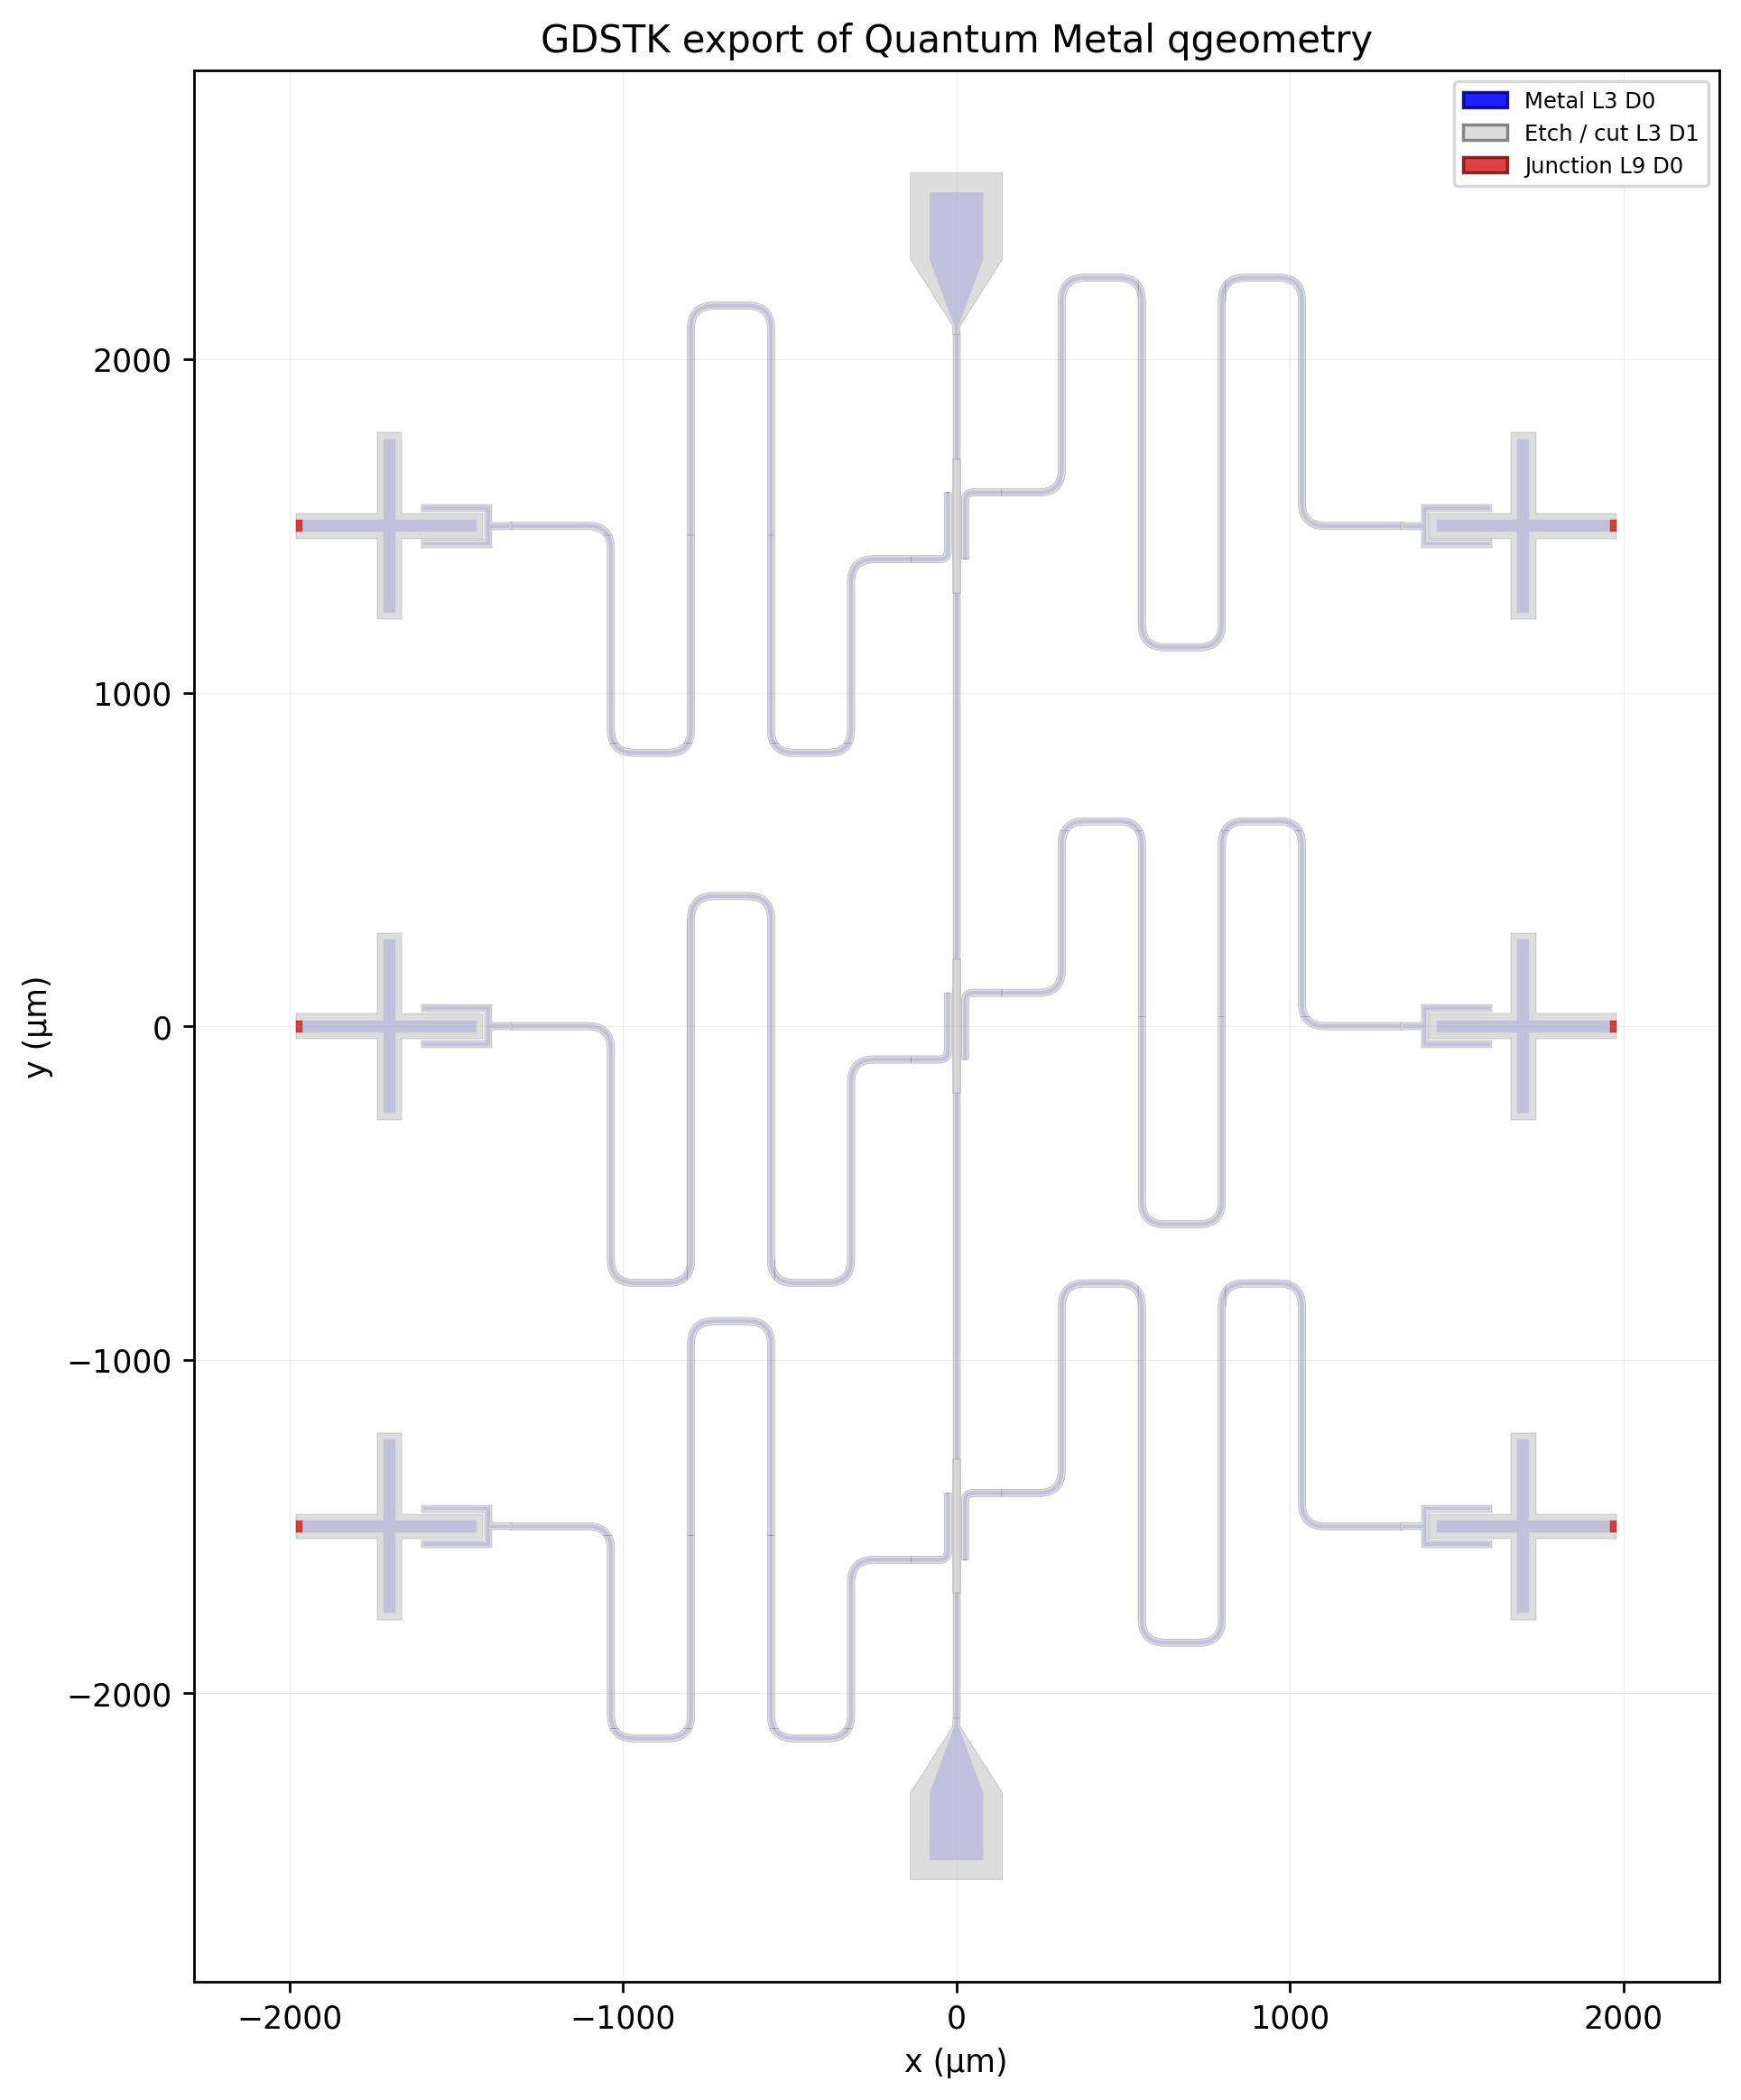

In [4]:
"""Six-qubit Quantum Metal layout.

This cell uses Quantum Metal to generate component qgeometry,
then exports those qgeometry tables directly to GDS with GDSTK
while preserving microwave CPW fillets.
"""

import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import GeometryCollection
from shapely.geometry import LineString
from shapely.geometry import MultiLineString
from shapely.geometry import MultiPolygon
from shapely.geometry import Polygon
from shapely.ops import transform

from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight

# =============================================================================
# CONTROL KNOBS
# =============================================================================

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/six_xmon_quantum_metal.gds"
)

WRITE_GDS: Final[bool] = True
RENDER_GDS: Final[bool] = True
SHOW_QGEOMETRY_SUMMARY: Final[bool] = True
SHOW_COMPONENT_PIN_AUDIT: Final[bool] = True
SHOW_FILLET_AUDIT: Final[bool] = True

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 11.0

CHIP_SIZE_X: Final[str] = "5mm"
CHIP_SIZE_Y: Final[str] = "5mm"

# Quantum Metal qgeometry coordinates are conventionally in millimeters.
# Exporting to GDSTK with this scale writes coordinates in micrometers.
COORD_SCALE_TO_UM: Final[float] = 1000.0
GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9

METAL_LAYER: Final[int] = 3
SUBTRACT_DATATYPE: Final[int] = 1
NORMAL_DATATYPE: Final[int] = 0
JUNCTION_LAYER: Final[int] = 9

TARGET_RESONATOR_FREQUENCIES_GHZ: Final[tuple[float, ...]] = (
    6.116,
    6.353,
    6.472,
    6.568,
    6.655,
    6.704,
)

CPW_PHASE_VELOCITY_M_PER_S: Final[float] = 1.20e8

FEEDLINE_TRACE_WIDTH: Final[str] = "11.7um"
FEEDLINE_TRACE_GAP: Final[str] = "5.1um"

ROUTE_TRACE_WIDTH: Final[str] = "10um"
ROUTE_TRACE_GAP: Final[str] = "6um"

# This is the Quantum Metal RouteMeander fillet request. The export code below
# clamps it if short local segments cannot support the requested radius.
RESONATOR_FILLET: Final[str] = "70um"
RESONATOR_MEANDER_SPACING: Final[str] = "240um"
RESONATOR_LEAD_START: Final[str] = "180um"
RESONATOR_LEAD_END: Final[str] = "140um"

DEFAULT_CROSS_LENGTH: Final[str] = "260um"
DEFAULT_CROSS_WIDTH: Final[str] = "35um"
DEFAULT_CROSS_GAP: Final[str] = "20um"

DEFAULT_CLAW_LENGTH: Final[str] = "190um"
DEFAULT_CLAW_WIDTH: Final[str] = "10um"
DEFAULT_CLAW_GAP: Final[str] = "6um"
DEFAULT_GROUND_SPACING: Final[str] = "5um"
DEFAULT_CLAW_CPW_LENGTH: Final[str] = "60um"
DEFAULT_CLAW_CPW_WIDTH: Final[str] = ROUTE_TRACE_WIDTH

DEFAULT_LJ_NH: Final[float] = 15.903982052718824
DEFAULT_COUPLING_LENGTH: Final[str] = "200um"
DEFAULT_COUPLING_SPACE: Final[str] = "4um"
DEFAULT_DOWN_LENGTH: Final[str] = "110um"

# Fillet reconstruction controls.
DEFAULT_ROUTE_FILLET_UM: Final[float] = 70.0
DEFAULT_COUPLER_FILLET_UM: Final[float] = 25.0
MIN_FILLET_RADIUS_UM: Final[float] = 8.0
FILLET_SAFETY_FRACTION: Final[float] = 0.42
SAMPLES_PER_FILLET: Final[int] = 18
BUFFER_RESOLUTION: Final[int] = 24

# Rendering styles. Normal geometry and subtract/cut geometry are shown with
# separate datatypes so KLayout and Matplotlib can distinguish them.
LAYER_STYLE_MAP: Final[dict[tuple[int, int], dict[str, str]]] = {
    (3, 0): {"facecolor": "#0000FF", "edgecolor": "#000080", "label": "Metal"},
    (3, 1): {"facecolor": "#D9D9D9", "edgecolor": "#777777", "label": "Etch / cut"},
    (9, 0): {"facecolor": "#D62728", "edgecolor": "#7F1010", "label": "Junction"},
}

DEFAULT_STYLE: Final[dict[str, str]] = {
    "facecolor": "#A0A0A0",
    "edgecolor": "#505050",
    "label": "Other",
}

QUBIT_SITES: Final[tuple[dict[str, Any], ...]] = (
    {
        "name": "Q1_L",
        "x": "-1700um",
        "y": "1500um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q2_L",
        "x": "-1700um",
        "y": "0um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "90um",
    },
    {
        "name": "Q3_L",
        "x": "-1700um",
        "y": "-1500um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q1_R",
        "x": "1700um",
        "y": "1500um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "90um",
    },
    {
        "name": "Q2_R",
        "x": "1700um",
        "y": "0um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q3_R",
        "x": "1700um",
        "y": "-1500um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "90um",
    },
)

mpl.rcParams["figure.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


# =============================================================================
# DATA STRUCTURES
# =============================================================================


@dataclass(frozen=True)
class ComponentHandles:
    """Created Quantum Metal component references."""

    wirebonds: list[Any]
    qubits: list[Any]
    tees: list[Any]
    resonators: list[Any]
    feedline: Any


# =============================================================================
# NUMERIC HELPERS
# =============================================================================


def quarter_wave_lengths_um(frequencies_ghz: tuple[float, ...]) -> np.ndarray:
    """Compute first-pass quarter-wave resonator lengths in micrometers."""
    frequencies = np.asarray(frequencies_ghz, dtype=np.float64)
    lengths_m = CPW_PHASE_VELOCITY_M_PER_S / (4.0 * frequencies * 1.0e9)
    return lengths_m * 1.0e6


def build_resonator_length_strings() -> list[str]:
    """Return Quantum Metal total_length strings."""
    lengths_um = quarter_wave_lengths_um(TARGET_RESONATOR_FREQUENCIES_GHZ)
    return [f"{length:.3f}um" for length in lengths_um]


# =============================================================================
# QUANTUM METAL BUILD
# =============================================================================


def create_design() -> Any:
    """Create a renderer-free planar design."""
    design = designs.DesignPlanar(
        overwrite_enabled=True,
        enable_renderers=False,
    )

    try:
        design.chips.main.size.size_x = CHIP_SIZE_X
        design.chips.main.size.size_y = CHIP_SIZE_Y
    except Exception:
        design._chips["main"]["size"]["size_x"] = CHIP_SIZE_X
        design._chips["main"]["size"]["size_y"] = CHIP_SIZE_Y

    design.variables["cpw_width"] = ROUTE_TRACE_WIDTH
    design.variables["cpw_gap"] = ROUTE_TRACE_GAP
    return design


def select_component_pin(
    component: Any,
    preferred: str,
    fallbacks: tuple[str, ...],
) -> str:
    """Return a valid pin name from a component."""
    pin_names = list(component.pins.keys())

    if preferred in pin_names:
        return preferred

    for candidate in fallbacks:
        if candidate in pin_names:
            return candidate

    raise ValueError(
        f"Could not find a usable pin on {component.name}. "
        f"Available pins are {pin_names}."
    )


def create_wirebond(
    design: Any,
    name: str,
    pos_y: str,
    orientation: str,
) -> Any:
    """Create a feedline wirebond launch pad."""
    return LaunchpadWirebond(
        design,
        name,
        options=Dict(
            pos_x="0um",
            pos_y=pos_y,
            orientation=orientation,
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            lead_length="25um",
            pad_width="160um",
            pad_height="200um",
            pad_gap="58um",
            taper_height="200um",
            layer=str(METAL_LAYER),
        ),
    )


def create_feedline(
    design: Any,
    top_launch: Any,
    bottom_launch: Any,
) -> Any:
    """Create the straight vertical CPW feedline."""
    top_pin = select_component_pin(top_launch, "tie", ("in", "out"))
    bottom_pin = select_component_pin(bottom_launch, "tie", ("in", "out"))

    return RouteStraight(
        design,
        "feedline",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=top_launch.name, pin=top_pin),
                end_pin=Dict(component=bottom_launch.name, pin=bottom_pin),
            ),
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            layer=str(METAL_LAYER),
        ),
    )


def create_qubit(
    design: Any,
    site: dict[str, Any],
) -> Any:
    """Create a cross qubit with a claw connector facing the feedline."""
    return TransmonCross(
        design,
        site["name"],
        options=Dict(
            connection_pads=Dict(
                c=Dict(
                    connector_location="90",
                    connector_type="0",
                    claw_length=DEFAULT_CLAW_LENGTH,
                    claw_gap=DEFAULT_CLAW_GAP,
                    claw_width=DEFAULT_CLAW_WIDTH,
                    claw_cpw_length=DEFAULT_CLAW_CPW_LENGTH,
                    claw_cpw_width=DEFAULT_CLAW_CPW_WIDTH,
                    ground_spacing=DEFAULT_GROUND_SPACING,
                )
            ),
            cross_length=DEFAULT_CROSS_LENGTH,
            cross_width=DEFAULT_CROSS_WIDTH,
            cross_gap=DEFAULT_CROSS_GAP,
            pos_x=site["x"],
            pos_y=site["y"],
            orientation=site["qubit_orientation"],
            hfss_inductance=f"{DEFAULT_LJ_NH}nH",
            aedt_hfss_inductance=f"{DEFAULT_LJ_NH}nH",
            layer=str(METAL_LAYER),
        ),
    )


def create_coupled_line_tee(
    design: Any,
    site: dict[str, Any],
) -> Any:
    """Create the feedline-side hanger coupler."""
    return CoupledLineTee(
        design,
        f"clt_{site['name']}",
        options=Dict(
            pos_x="0um",
            pos_y=site["y"],
            orientation=site["clt_orientation"],
            prime_width=FEEDLINE_TRACE_WIDTH,
            prime_gap=FEEDLINE_TRACE_GAP,
            second_width=ROUTE_TRACE_WIDTH,
            second_gap=ROUTE_TRACE_GAP,
            coupling_space=DEFAULT_COUPLING_SPACE,
            coupling_length=DEFAULT_COUPLING_LENGTH,
            down_length=DEFAULT_DOWN_LENGTH,
            fillet="25um",
            open_termination=False,
            layer=str(METAL_LAYER),
        ),
    )


def select_tee_output_pin(tee: Any) -> str:
    """Return the output pin on the coupled-line tee."""
    pin_names = tuple(tee.pins.keys())

    for candidate in ("second_end", "second", "out", "prime_end"):
        if candidate in pin_names:
            return candidate

    for pin_name in pin_names:
        if "second" in pin_name:
            return pin_name

    raise ValueError(
        f"Could not find a tee output pin on {tee.name}. "
        f"Available pins are {list(pin_names)}."
    )


def create_readout_resonator(
    design: Any,
    site: dict[str, Any],
    tee: Any,
    qubit: Any,
    total_length: str,
) -> Any:
    """Create a meander from CLT output to the qubit claw pin."""
    tee_pin = select_tee_output_pin(tee)
    qubit_pin = select_component_pin(qubit, "c", tuple(qubit.pins.keys()))

    return RouteMeander(
        design,
        f"rr_{site['name']}",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=tee.name, pin=tee_pin),
                end_pin=Dict(component=qubit.name, pin=qubit_pin),
            ),
            lead=Dict(
                start_straight=RESONATOR_LEAD_START,
                end_straight=RESONATOR_LEAD_END,
            ),
            fillet=RESONATOR_FILLET,
            total_length=total_length,
            trace_width=ROUTE_TRACE_WIDTH,
            trace_gap=ROUTE_TRACE_GAP,
            meander=Dict(
                spacing=RESONATOR_MEANDER_SPACING,
                asymmetry=site["meander_asymmetry"],
            ),
            prevent_short_edges="true",
            snap="true",
            layer=str(METAL_LAYER),
        ),
    )


def build_chip() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the complete six-qubit chip without starting renderers."""
    design = create_design()

    top_launch = create_wirebond(
        design=design,
        name="wb_top",
        pos_y="2100um",
        orientation="-90",
    )
    bottom_launch = create_wirebond(
        design=design,
        name="wb_bottom",
        pos_y="-2100um",
        orientation="90",
    )
    feedline = create_feedline(design, top_launch, bottom_launch)

    target_lengths = build_resonator_length_strings()

    qubits: list[Any] = []
    tees: list[Any] = []
    resonators: list[Any] = []
    summary_records: list[dict[str, Any]] = []

    for index, site in enumerate(QUBIT_SITES):
        qubit = create_qubit(design, site)
        tee = create_coupled_line_tee(design, site)
        resonator = create_readout_resonator(
            design=design,
            site=site,
            tee=tee,
            qubit=qubit,
            total_length=target_lengths[index],
        )

        qubits.append(qubit)
        tees.append(tee)
        resonators.append(resonator)

        summary_records.append(
            {
                "qubit": site["name"],
                "x": site["x"],
                "y": site["y"],
                "qubit_orientation": site["qubit_orientation"],
                "clt_orientation": site["clt_orientation"],
                "target_frequency_ghz": TARGET_RESONATOR_FREQUENCIES_GHZ[index],
                "route_total_length": target_lengths[index],
                "meander_asymmetry": site["meander_asymmetry"],
            }
        )

    handles = ComponentHandles(
        wirebonds=[top_launch, bottom_launch],
        qubits=qubits,
        tees=tees,
        resonators=resonators,
        feedline=feedline,
    )
    summary = pd.DataFrame(summary_records)

    return design, handles, summary


# =============================================================================
# DIRECT QGEOMETRY TO FILLETED GDSTK EXPORT
# =============================================================================


def parse_bool(value: Any) -> bool:
    """Parse a possible bool-like qgeometry value."""
    if isinstance(value, bool):
        return value

    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}

    try:
        return bool(value)
    except Exception:
        return False


def parse_layer(value: Any, fallback: int = METAL_LAYER) -> int:
    """Parse a qgeometry layer value."""
    try:
        if pd.isna(value):
            return fallback
    except Exception:
        pass

    try:
        return int(value)
    except Exception:
        return fallback


def parse_value_mm(
    design: Any,
    value: Any,
    fallback_mm: float,
) -> float:
    """Parse a Quantum Metal value into millimeters."""
    if value is None:
        return fallback_mm

    try:
        if pd.isna(value):
            return fallback_mm
    except Exception:
        pass

    try:
        return float(design.parse_value(value))
    except Exception:
        pass

    try:
        return float(value)
    except Exception:
        return fallback_mm


def parse_value_um(
    design: Any,
    value: Any,
    fallback_um: float,
) -> float:
    """Parse a Quantum Metal value into micrometers."""
    value_mm = parse_value_mm(
        design=design,
        value=value,
        fallback_mm=fallback_um / COORD_SCALE_TO_UM,
    )
    return value_mm * COORD_SCALE_TO_UM


def component_lookup_by_id(design: Any) -> dict[int, Any]:
    """Map Quantum Metal component IDs to component objects."""
    lookup: dict[int, Any] = {}

    for component in design.components.values():
        component_id = getattr(component, "id", None)

        if component_id is None:
            component_id = getattr(component, "_id", None)

        if component_id is None:
            continue

        try:
            lookup[int(component_id)] = component
        except Exception:
            continue

    return lookup


def component_for_row(
    design: Any,
    row: pd.Series,
    lookup: dict[int, Any],
) -> Any | None:
    """Return the component associated with a qgeometry row."""
    component_value = row.get("component")

    try:
        return lookup.get(int(component_value))
    except Exception:
        pass

    if isinstance(component_value, str):
        try:
            return design.components[component_value]
        except Exception:
            return None

    return None


def get_option(component: Any | None, key: str) -> Any | None:
    """Read a component option if present."""
    if component is None:
        return None

    options = getattr(component, "options", None)
    if options is None:
        return None

    try:
        return options[key]
    except Exception:
        pass

    try:
        return options.get(key)
    except Exception:
        return None


def trace_width_um(
    design: Any,
    row: pd.Series,
    component: Any | None,
) -> float:
    """Return the trace width for a LineString row."""
    row_width = row.get("width")

    if row_width is not None:
        return parse_value_um(
            design=design,
            value=row_width,
            fallback_um=10.0,
        )

    for key in ("trace_width", "second_width", "prime_width", "claw_width"):
        value = get_option(component, key)

        if value is not None:
            return parse_value_um(
                design=design,
                value=value,
                fallback_um=10.0,
            )

    return 10.0


def requested_fillet_um(
    design: Any,
    component: Any | None,
) -> float:
    """Return the intended microwave route fillet in micrometers."""
    class_name = component.__class__.__name__ if component is not None else ""

    option_value = get_option(component, "fillet")
    if option_value is not None:
        return parse_value_um(
            design=design,
            value=option_value,
            fallback_um=DEFAULT_ROUTE_FILLET_UM,
        )

    if "Route" in class_name:
        return DEFAULT_ROUTE_FILLET_UM

    if "CoupledLineTee" in class_name:
        return DEFAULT_COUPLER_FILLET_UM

    return 0.0


def scale_geometry_to_um(geometry: Any) -> Any:
    """Scale Shapely geometry from millimeters to micrometers."""
    return transform(
        lambda x_coord, y_coord, z_coord=None: (
            x_coord * COORD_SCALE_TO_UM,
            y_coord * COORD_SCALE_TO_UM,
        ),
        geometry,
    )


def clean_coords(coords: Any) -> np.ndarray:
    """Return polygon coordinates without duplicated closure."""
    points = np.asarray(coords, dtype=float)

    if len(points) >= 2 and np.allclose(points[0], points[-1]):
        points = points[:-1]

    return points


def clean_line_points(points: np.ndarray) -> np.ndarray:
    """Remove repeated consecutive centerline points."""
    cleaned: list[np.ndarray] = []

    for point in np.asarray(points, dtype=float):
        if len(cleaned) == 0:
            cleaned.append(point)
            continue

        if np.linalg.norm(point - cleaned[-1]) > 1.0e-9:
            cleaned.append(point)

    return np.asarray(cleaned, dtype=float)


def quadratic_bezier_points(
    start: np.ndarray,
    control: np.ndarray,
    end: np.ndarray,
    samples: int,
) -> np.ndarray:
    """Sample a quadratic Bezier fillet segment."""
    t_values = np.linspace(0.0, 1.0, samples + 2)
    return (
        ((1.0 - t_values) ** 2)[:, None] * start[None, :]
        + (2.0 * (1.0 - t_values) * t_values)[:, None] * control[None, :]
        + (t_values**2)[:, None] * end[None, :]
    )


def safe_corner_radius_um(
    points: np.ndarray,
    requested_radius_um: float,
) -> float:
    """Clamp the requested fillet radius to available segment lengths."""
    if points.shape[0] < 3 or requested_radius_um <= 0.0:
        return 0.0

    segment_lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    if segment_lengths.shape[0] < 2:
        return 0.0

    adjacent_limits = [
        min(segment_lengths[index - 1], segment_lengths[index])
        for index in range(1, points.shape[0] - 1)
    ]

    if len(adjacent_limits) == 0:
        return 0.0

    allowed_radius = FILLET_SAFETY_FRACTION * min(adjacent_limits)
    radius = min(float(requested_radius_um), float(allowed_radius))

    if radius < MIN_FILLET_RADIUS_UM:
        return 0.0

    return radius


def rounded_centerline_um(
    line: LineString,
    requested_radius_um: float,
) -> tuple[np.ndarray, float]:
    """Return a rounded centerline sampled in micrometers and its radius."""
    raw_points = np.asarray(line.coords, dtype=float) * COORD_SCALE_TO_UM
    points = clean_line_points(raw_points)

    if points.shape[0] <= 2:
        return points, 0.0

    radius_um = safe_corner_radius_um(points, requested_radius_um)

    if radius_um <= 0.0:
        return points, 0.0

    output: list[np.ndarray] = [points[0]]

    for index in range(1, points.shape[0] - 1):
        previous_point = points[index - 1]
        corner_point = points[index]
        next_point = points[index + 1]

        incoming = corner_point - previous_point
        outgoing = next_point - corner_point

        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))

        if incoming_length <= 1.0e-12 or outgoing_length <= 1.0e-12:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length

        cosine_angle = float(np.clip(np.dot(incoming_unit, outgoing_unit), -1.0, 1.0))
        deflection = math.acos(cosine_angle)

        if deflection <= 1.0e-9 or abs(math.pi - deflection) <= 1.0e-9:
            output.append(corner_point)
            continue

        trim_um = radius_um * math.tan(0.5 * deflection)
        trim_um = min(trim_um, 0.45 * incoming_length, 0.45 * outgoing_length)

        entry_point = corner_point - incoming_unit * trim_um
        exit_point = corner_point + outgoing_unit * trim_um

        if np.linalg.norm(output[-1] - entry_point) > 1.0e-9:
            output.append(entry_point)

        curve = quadratic_bezier_points(
            start=entry_point,
            control=corner_point,
            end=exit_point,
            samples=SAMPLES_PER_FILLET,
        )

        for curve_point in curve[1:]:
            output.append(curve_point)

    if np.linalg.norm(output[-1] - points[-1]) > 1.0e-9:
        output.append(points[-1])

    return np.asarray(output, dtype=float), radius_um


def line_to_rounded_polygon(
    line: LineString,
    width_um: float,
    requested_radius_um: float,
) -> tuple[Polygon, float]:
    """Convert a centerline into a rounded CPW trace polygon."""
    centerline, used_radius_um = rounded_centerline_um(
        line=line,
        requested_radius_um=requested_radius_um,
    )

    if centerline.shape[0] < 2:
        return Polygon(), used_radius_um

    trace = LineString(centerline).buffer(
        0.5 * width_um,
        cap_style=2,
        join_style=1,
        resolution=BUFFER_RESOLUTION,
    )
    return trace, used_radius_um


def polygon_to_gdstk(
    polygon: Polygon,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert a Shapely polygon, including holes, into GDSTK polygons."""
    if polygon.is_empty or polygon.area <= 0.0:
        return []

    outer = gdstk.Polygon(
        clean_coords(polygon.exterior.coords),
        layer=layer,
        datatype=datatype,
    )

    holes = [
        gdstk.Polygon(
            clean_coords(interior.coords),
            layer=layer,
            datatype=datatype,
        )
        for interior in polygon.interiors
    ]

    if len(holes) == 0:
        return [outer]

    return gdstk.boolean(
        [outer],
        holes,
        "not",
        precision=1.0e-3,
        layer=layer,
        datatype=datatype,
    )


def geometry_to_gdstk(
    geometry: Any,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert Shapely polygonal geometry into GDSTK polygons."""
    if geometry.is_empty:
        return []

    if isinstance(geometry, Polygon):
        return polygon_to_gdstk(geometry, layer, datatype)

    if isinstance(geometry, MultiPolygon):
        polygons: list[gdstk.Polygon] = []
        for polygon in geometry.geoms:
            polygons.extend(polygon_to_gdstk(polygon, layer, datatype))
        return polygons

    if isinstance(geometry, GeometryCollection):
        polygons: list[gdstk.Polygon] = []
        for item in geometry.geoms:
            polygons.extend(geometry_to_gdstk(item, layer, datatype))
        return polygons

    return []


def row_geometry_to_polygons(
    design: Any,
    table_name: str,
    row: pd.Series,
    lookup: dict[int, Any],
    fillet_records: list[dict[str, Any]],
) -> list[gdstk.Polygon]:
    """Convert one qgeometry row to one or more GDSTK polygons."""
    geometry = row.get("geometry")

    if geometry is None or geometry.is_empty:
        return []

    component = component_for_row(design, row, lookup)
    component_name = getattr(component, "name", "unknown")
    component_class = component.__class__.__name__ if component is not None else "unknown"

    layer = parse_layer(row.get("layer"), fallback=METAL_LAYER)
    subtract = parse_bool(row.get("subtract", False))
    datatype = SUBTRACT_DATATYPE if subtract else NORMAL_DATATYPE

    if table_name == "junction":
        layer = JUNCTION_LAYER
        datatype = NORMAL_DATATYPE

    if isinstance(geometry, LineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        rounded_geometry, used_radius = line_to_rounded_polygon(
            line=geometry,
            width_um=width_um,
            requested_radius_um=fillet_um,
        )

        fillet_records.append(
            {
                "table": table_name,
                "component": component_name,
                "class": component_class,
                "width_um": width_um,
                "requested_fillet_um": fillet_um,
                "used_fillet_um": used_radius,
            }
        )

        return geometry_to_gdstk(rounded_geometry, layer, datatype)

    if isinstance(geometry, MultiLineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        polygons: list[gdstk.Polygon] = []

        for line in geometry.geoms:
            rounded_geometry, used_radius = line_to_rounded_polygon(
                line=line,
                width_um=width_um,
                requested_radius_um=fillet_um,
            )
            polygons.extend(geometry_to_gdstk(rounded_geometry, layer, datatype))

            fillet_records.append(
                {
                    "table": table_name,
                    "component": component_name,
                    "class": component_class,
                    "width_um": width_um,
                    "requested_fillet_um": fillet_um,
                    "used_fillet_um": used_radius,
                }
            )

        return polygons

    scaled_geometry = scale_geometry_to_um(geometry)
    return geometry_to_gdstk(scaled_geometry, layer, datatype)


def export_qgeometry_to_gds(
    design: Any,
    output_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Export Quantum Metal qgeometry tables through GDSTK with fillets."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    top_cell = library.new_cell("TOP")

    all_polygons: list[gdstk.Polygon] = []
    export_records: list[dict[str, Any]] = []
    fillet_records: list[dict[str, Any]] = []
    lookup = component_lookup_by_id(design)

    for table_name, table in design.qgeometry.tables.items():
        if table is None or table.empty:
            continue

        for _, row in table.iterrows():
            polygons = row_geometry_to_polygons(
                design=design,
                table_name=table_name,
                row=row,
                lookup=lookup,
                fillet_records=fillet_records,
            )
            all_polygons.extend(polygons)

            for polygon in polygons:
                export_records.append(
                    {
                        "table": table_name,
                        "layer": int(polygon.layer),
                        "datatype": int(polygon.datatype),
                        "vertices": int(len(polygon.points)),
                        "area_um2": float(abs(polygon.area())),
                    }
                )

    if len(all_polygons) == 0:
        raise RuntimeError("No qgeometry polygons were produced for GDSTK export.")

    top_cell.add(*all_polygons)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if WRITE_GDS:
        library.write_gds(str(output_path))

    return pd.DataFrame(export_records), pd.DataFrame(fillet_records)


# =============================================================================
# AUDIT AND RENDER
# =============================================================================


def audit_component_pins(design: Any) -> pd.DataFrame:
    """Return a table of component names and pin names."""
    records: list[dict[str, str]] = []

    for name, component in design.components.items():
        records.append(
            {
                "component": name,
                "class": component.__class__.__name__,
                "pins": ",".join(component.pins.keys()),
            }
        )

    return pd.DataFrame(records).sort_values("component").reset_index(drop=True)


def summarize_export(export_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize the direct GDSTK export by table, layer, and datatype."""
    return (
        export_table.groupby(["table", "layer", "datatype"], as_index=False)
        .agg(
            polygon_count=("area_um2", "size"),
            total_area_um2=("area_um2", "sum"),
            min_vertices=("vertices", "min"),
            max_vertices=("vertices", "max"),
        )
        .sort_values(["table", "layer", "datatype"])
        .reset_index(drop=True)
    )


def summarize_fillets(fillet_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize requested and used fillet radii by component class."""
    if fillet_table.empty:
        return pd.DataFrame()

    return (
        fillet_table.groupby(["class"], as_index=False)
        .agg(
            line_count=("used_fillet_um", "size"),
            width_min_um=("width_um", "min"),
            width_max_um=("width_um", "max"),
            requested_fillet_max_um=("requested_fillet_um", "max"),
            used_fillet_min_um=("used_fillet_um", "min"),
            used_fillet_max_um=("used_fillet_um", "max"),
        )
        .sort_values("class")
        .reset_index(drop=True)
    )


def load_exported_polygons(gds_path: Path) -> list[gdstk.Polygon]:
    """Load polygons from the exported GDS."""
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError("The exported GDS has no top-level cells.")

    return top_cells[0].get_polygons(depth=None)


def style_for_polygon(polygon: gdstk.Polygon) -> dict[str, str]:
    """Return style for a GDSTK polygon."""
    return LAYER_STYLE_MAP.get(
        (int(polygon.layer), int(polygon.datatype)),
        DEFAULT_STYLE,
    )


def render_exported_gds(gds_path: Path) -> None:
    """Render the exported GDS with Matplotlib."""
    polygons = load_exported_polygons(gds_path)

    if len(polygons) == 0:
        raise RuntimeError("No polygons were found in the exported GDS.")

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    legend_entries: dict[tuple[int, int], Patch] = {}

    keys = sorted({(int(poly.layer), int(poly.datatype)) for poly in polygons})

    for key in keys:
        key_polygons = [
            poly
            for poly in polygons
            if (int(poly.layer), int(poly.datatype)) == key
        ]
        style = style_for_polygon(key_polygons[0])

        patches = [
            MplPolygon(np.asarray(poly.points), closed=True)
            for poly in key_polygons
        ]

        collection = PatchCollection(
            patches,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=0.10,
            alpha=0.88,
        )
        ax.add_collection(collection)

        legend_entries[key] = Patch(
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            label=f'{style["label"]} L{key[0]} D{key[1]}',
            alpha=0.88,
        )

    all_points = np.vstack([np.asarray(poly.points) for poly in polygons])
    x_min = float(np.min(all_points[:, 0]))
    x_max = float(np.max(all_points[:, 0]))
    y_min = float(np.min(all_points[:, 1]))
    y_max = float(np.max(all_points[:, 1]))

    span = max(x_max - x_min, y_max - y_min)
    margin = 0.06 * span

    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title("GDSTK export of Quantum Metal qgeometry")
    ax.grid(True, linewidth=0.25, alpha=0.25)
    ax.legend(handles=list(legend_entries.values()), fontsize=7, loc="upper right")

    plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================


def main() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the chip, export qgeometry directly, and render the GDS."""
    print("Creating DesignPlanar with enable_renderers=False.")
    print("Exporting Quantum Metal qgeometry through a fillet-preserving GDSTK path.")

    design, handles, summary = build_chip()

    print("\nSix-qubit resonator plan")
    display(summary)

    if SHOW_COMPONENT_PIN_AUDIT:
        print("\nComponent pin audit")
        display(audit_component_pins(design))

    export_table, fillet_table = export_qgeometry_to_gds(
        design=design,
        output_path=OUTPUT_GDS_PATH,
    )

    if WRITE_GDS:
        print(f"\nWrote GDSTK GDS: {OUTPUT_GDS_PATH}")

    if SHOW_QGEOMETRY_SUMMARY:
        print("\nDirect export summary")
        display(
            summarize_export(export_table).style.format(
                {"total_area_um2": "{:.6e}"}
            )
        )

    if SHOW_FILLET_AUDIT:
        print("\nFillet audit")
        display(
            summarize_fillets(fillet_table).style.format(
                {
                    "width_min_um": "{:.3f}",
                    "width_max_um": "{:.3f}",
                    "requested_fillet_max_um": "{:.3f}",
                    "used_fillet_min_um": "{:.3f}",
                    "used_fillet_max_um": "{:.3f}",
                }
            )
        )

    if RENDER_GDS:
        render_exported_gds(OUTPUT_GDS_PATH)

    return design, handles, summary


design, component_handles, resonator_plan = main()

This next layout produces the same chip layout, but with cheesing to prevent Abrikosov vortices.

Creating DesignPlanar with enable_renderers=False.
Exporting Quantum Metal qgeometry through a fillet preserving GDSTK path.

Six qubit resonator plan


,qubit,x,y,qubit_orientation,clt_orientation,target_frequency_ghz,route_total_length,meander_asymmetry
0,Q1_L,-1700um,1500um,-90,-90,6.116,4905.167um,-90um
1,Q2_L,-1700um,0um,-90,-90,6.353,4722.178um,90um
2,Q3_L,-1700um,-1500um,-90,-90,6.472,4635.352um,-90um
3,Q1_R,1700um,1500um,90,90,6.568,4567.600um,90um
4,Q2_R,1700um,0um,90,90,6.655,4507.889um,-90um
5,Q3_R,1700um,-1500um,90,90,6.704,4474.940um,90um



Component pin audit


,component,class,pins
0,Q1_L,TransmonCross,c
1,Q1_R,TransmonCross,c
2,Q2_L,TransmonCross,c
3,Q2_R,TransmonCross,c
4,Q3_L,TransmonCross,c
5,Q3_R,TransmonCross,c
6,clt_Q1_L,CoupledLineTee,"prime_start,prime_end,second_end"
7,clt_Q1_R,CoupledLineTee,"prime_start,prime_end,second_end"
8,clt_Q2_L,CoupledLineTee,"prime_start,prime_end,second_end"
9,clt_Q2_R,CoupledLineTee,"prime_start,prime_end,second_end"



Wrote GDSTK GDS: /content/six_xmon_cheesing_quantum_metal.gds

Direct export summary


,layer,datatype,polygon_count,total_area_um2,min_vertices,max_vertices
0,3,0,33,7.179400e+05,4,532
1,3,1,228122,2.459648e+06,4,532
2,9,0,6,4.200000e+03,4,4



Fillet audit


,class,line_count,width_min_um,width_max_um,requested_fillet_max_um,used_fillet_min_um,used_fillet_max_um
0,CoupledLineTee,24,10.000,22.000,25.000,0.000,25.000
1,RouteMeander,12,10.000,22.000,70.000,70.000,70.000
2,RouteStraight,2,11.700,21.900,0.000,0.000,0.000
3,TransmonCross,6,35.000,35.000,70.000,0.000,0.000


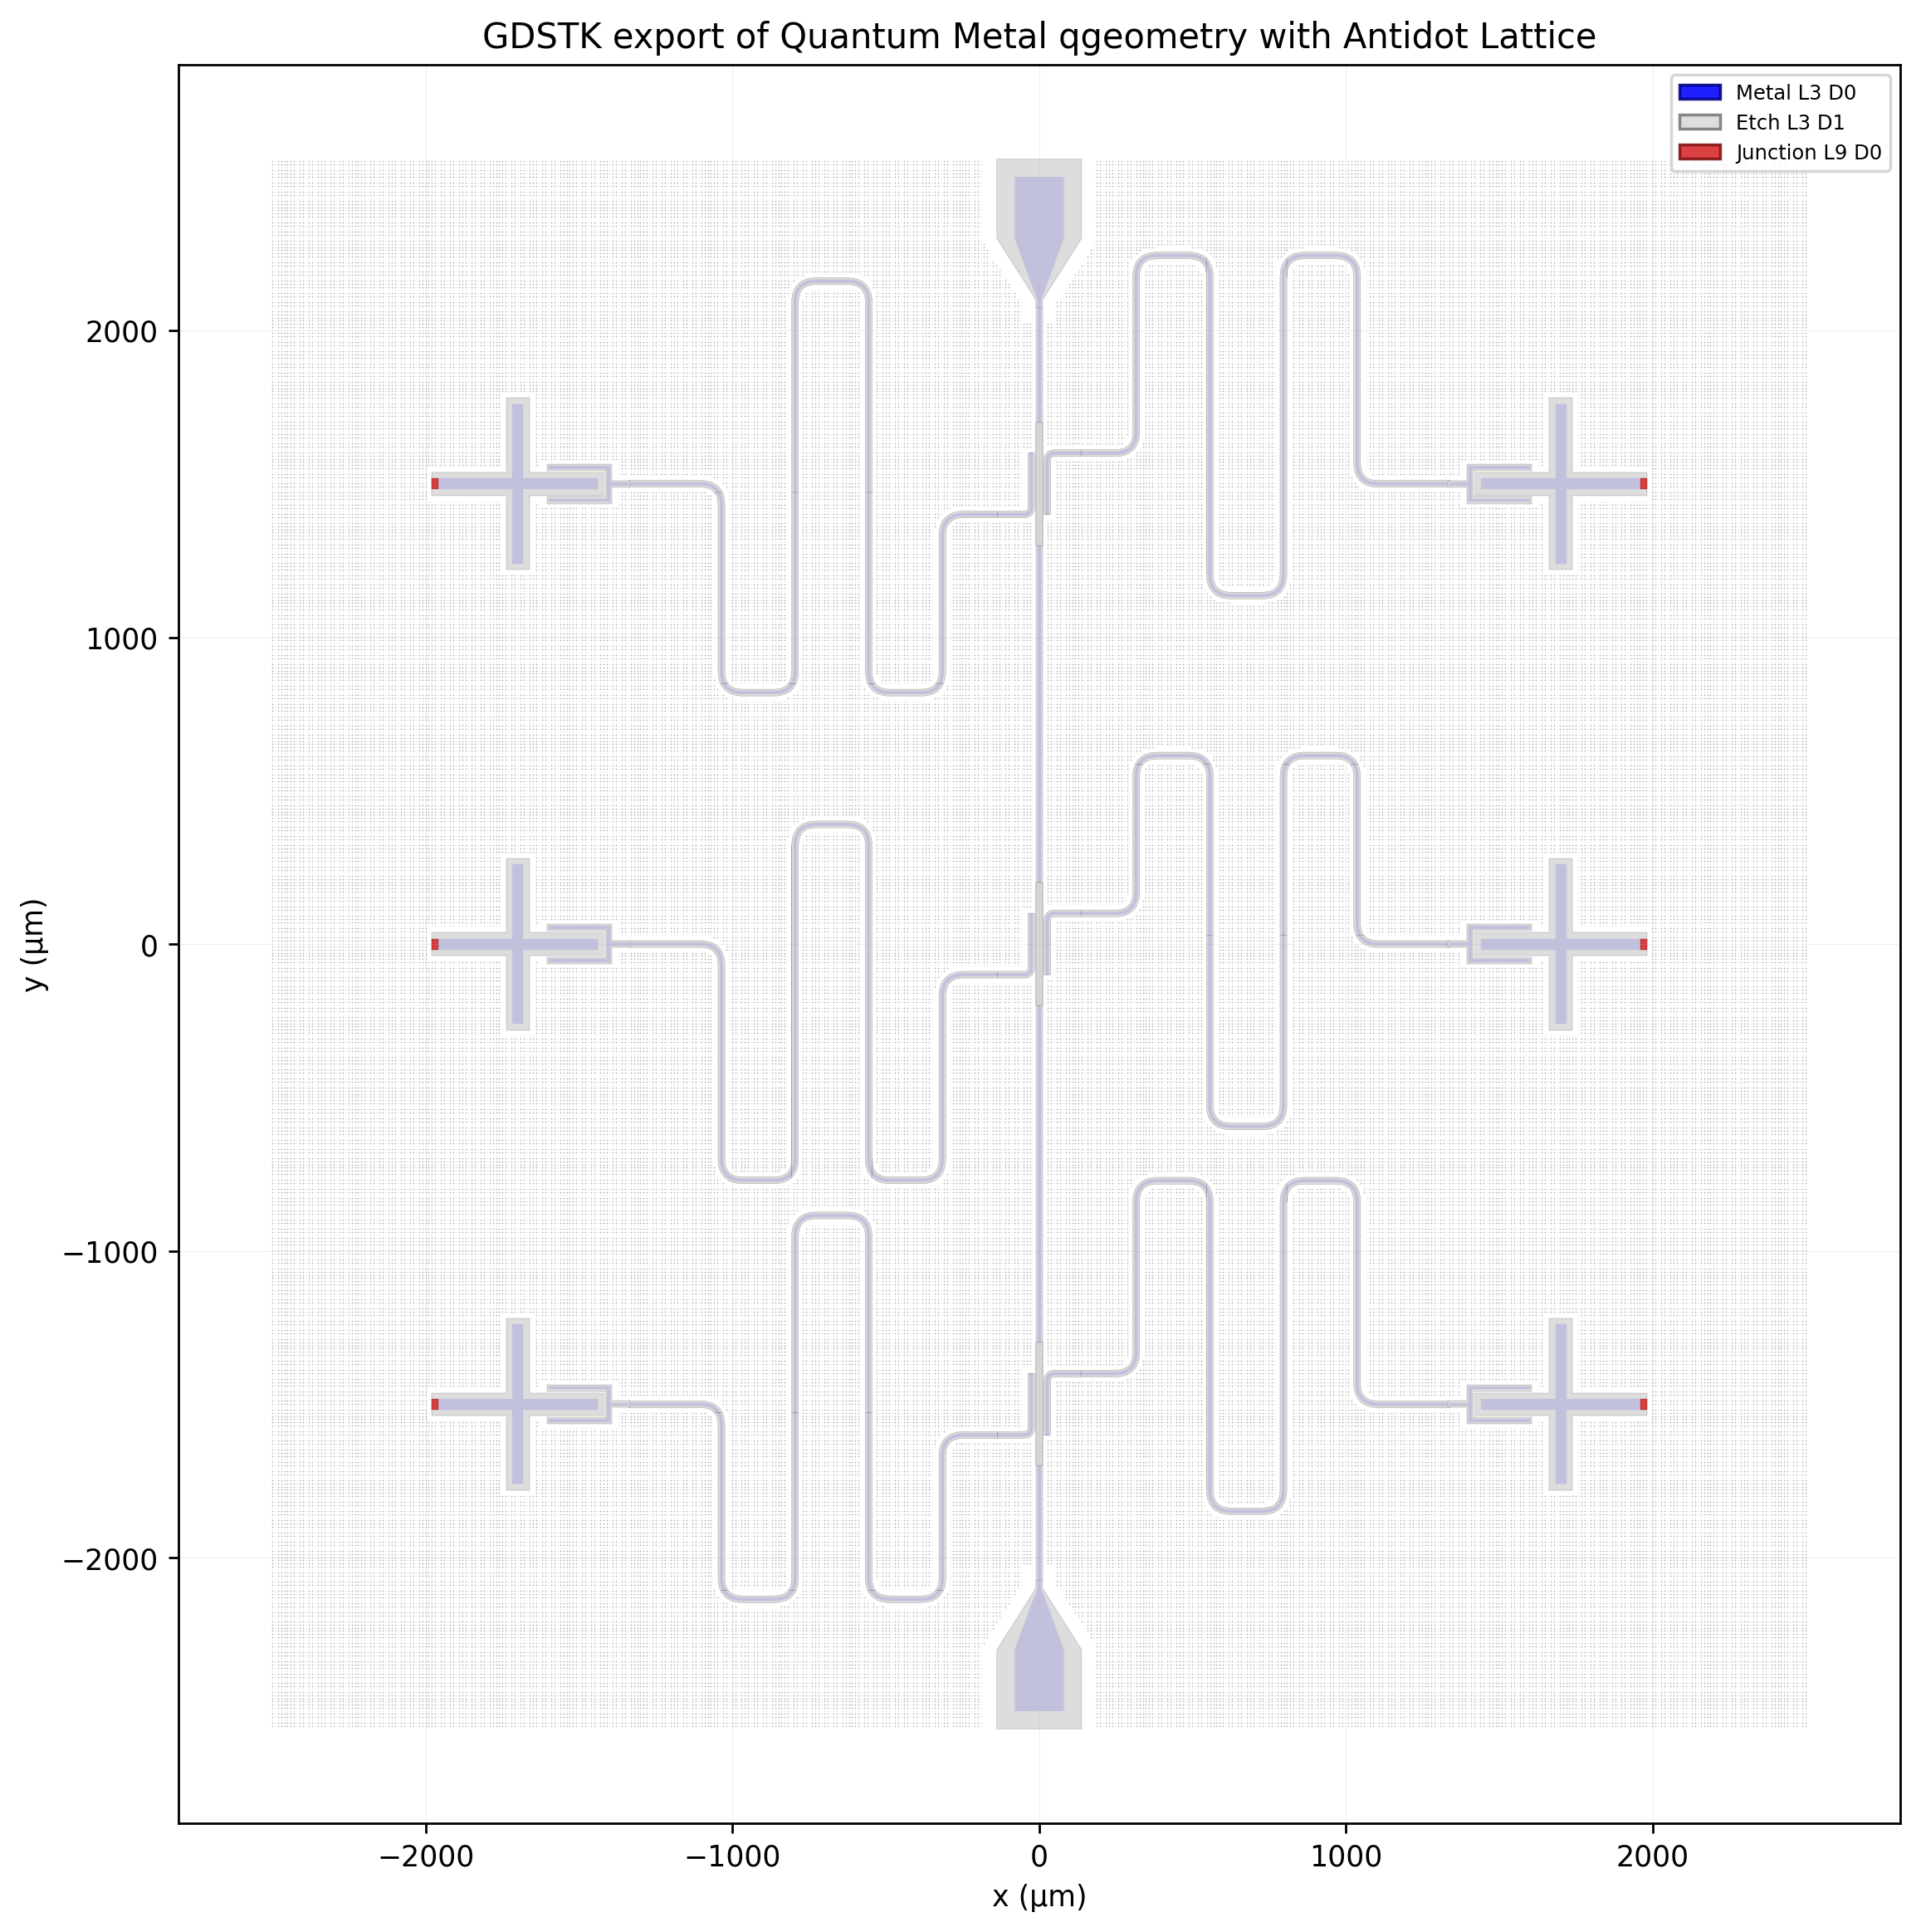

In [8]:
"""This script defines a six-qubit Quantum Metal layout.

This script uses Quantum Metal to generate component qgeometry,
then exports those qgeometry tables directly to GDS with GDSTK
while preserving microwave CPW fillets and generating an optimal
antidot lattice to prevent Abrikosov vortex mobility.
"""

import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import GeometryCollection
from shapely.geometry import LineString
from shapely.geometry import MultiLineString
from shapely.geometry import MultiPolygon
from shapely.geometry import Polygon
from shapely.ops import transform

from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight

# =============================================================================
# CONTROL KNOBS
# =============================================================================

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/six_xmon_cheesing_quantum_metal.gds"
)

WRITE_GDS: Final[bool] = True
RENDER_GDS: Final[bool] = True
SHOW_QGEOMETRY_SUMMARY: Final[bool] = True
SHOW_COMPONENT_PIN_AUDIT: Final[bool] = True
SHOW_FILLET_AUDIT: Final[bool] = True

# Antidot Lattice Generation Controls
ENABLE_ANTIDOTS: Final[bool] = True
ANTIDOT_PITCH_UM: Final[float] = 10.0
ANTIDOT_SIZE_UM: Final[float] = 2.0
ANTIDOT_OFFSET_X_UM: Final[float] = 9.0
ANTIDOT_OFFSET_Y_UM: Final[float] = 0.0
ANTIDOT_EXTENSION_Y_UM: Final[float] = 60.0
ANTIDOT_KEEPOUT_UM: Final[float] = 15.0
LAUNCHPAD_KEEPOUT_UM: Final[float] = 45.0

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 11.0

CHIP_SIZE_X: Final[str] = "5mm"
CHIP_SIZE_Y: Final[str] = "5mm"

# Quantum Metal qgeometry coordinates are conventionally in millimeters.
# Exporting to GDSTK with this scale writes coordinates in micrometers.
COORD_SCALE_TO_UM: Final[float] = 1000.0
GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9

METAL_LAYER: Final[int] = 3
SUBTRACT_DATATYPE: Final[int] = 1
NORMAL_DATATYPE: Final[int] = 0
JUNCTION_LAYER: Final[int] = 9

TARGET_RESONATOR_FREQUENCIES_GHZ: Final[tuple[float, ...]] = (
    6.116,
    6.353,
    6.472,
    6.568,
    6.655,
    6.704,
)

CPW_PHASE_VELOCITY_M_PER_S: Final[float] = 1.20e8

FEEDLINE_TRACE_WIDTH: Final[str] = "11.7um"
FEEDLINE_TRACE_GAP: Final[str] = "5.1um"

ROUTE_TRACE_WIDTH: Final[str] = "10um"
ROUTE_TRACE_GAP: Final[str] = "6um"

# This is the Quantum Metal RouteMeander fillet request. The export code below
# clamps it if short local segments cannot support the requested radius.
RESONATOR_FILLET: Final[str] = "70um"
RESONATOR_MEANDER_SPACING: Final[str] = "240um"
RESONATOR_LEAD_START: Final[str] = "180um"
RESONATOR_LEAD_END: Final[str] = "140um"

DEFAULT_CROSS_LENGTH: Final[str] = "260um"
DEFAULT_CROSS_WIDTH: Final[str] = "35um"
DEFAULT_CROSS_GAP: Final[str] = "20um"

DEFAULT_CLAW_LENGTH: Final[str] = "190um"
DEFAULT_CLAW_WIDTH: Final[str] = "10um"
DEFAULT_CLAW_GAP: Final[str] = "6um"
DEFAULT_GROUND_SPACING: Final[str] = "5um"
DEFAULT_CLAW_CPW_LENGTH: Final[str] = "60um"
DEFAULT_CLAW_CPW_WIDTH: Final[str] = ROUTE_TRACE_WIDTH

DEFAULT_LJ_NH: Final[float] = 15.903982052718824
DEFAULT_COUPLING_LENGTH: Final[str] = "200um"
DEFAULT_COUPLING_SPACE: Final[str] = "4um"
DEFAULT_DOWN_LENGTH: Final[str] = "110um"

# Fillet reconstruction controls.
DEFAULT_ROUTE_FILLET_UM: Final[float] = 70.0
DEFAULT_COUPLER_FILLET_UM: Final[float] = 25.0
MIN_FILLET_RADIUS_UM: Final[float] = 8.0
FILLET_SAFETY_FRACTION: Final[float] = 0.42
SAMPLES_PER_FILLET: Final[int] = 18
BUFFER_RESOLUTION: Final[int] = 24

# Rendering styles. Normal geometry and subtract/cut geometry are shown with
# separate datatypes so KLayout and Matplotlib can distinguish them.
LAYER_STYLE_MAP: Final[dict[tuple[int, int], dict[str, str]]] = {
    (3, 0): {"facecolor": "#0000FF", "edgecolor": "#000080", "label": "Metal"},
    (3, 1): {"facecolor": "#D9D9D9", "edgecolor": "#777777", "label": "Etch"},
    (9, 0): {"facecolor": "#D62728", "edgecolor": "#7F1010", "label": "Junction"},
}

DEFAULT_STYLE: Final[dict[str, str]] = {
    "facecolor": "#A0A0A0",
    "edgecolor": "#505050",
    "label": "Other",
}

QUBIT_SITES: Final[tuple[dict[str, Any], ...]] = (
    {
        "name": "Q1_L",
        "x": "-1700um",
        "y": "1500um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q2_L",
        "x": "-1700um",
        "y": "0um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "90um",
    },
    {
        "name": "Q3_L",
        "x": "-1700um",
        "y": "-1500um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q1_R",
        "x": "1700um",
        "y": "1500um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "90um",
    },
    {
        "name": "Q2_R",
        "x": "1700um",
        "y": "0um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q3_R",
        "x": "1700um",
        "y": "-1500um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "90um",
    },
)

# Enforce formal publishing parameters for scientific illustrations.
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["figure.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


# =============================================================================
# DATA STRUCTURES
# =============================================================================


@dataclass(frozen=True)
class ComponentHandles:
    """Created Quantum Metal component references."""

    wirebonds: list[Any]
    qubits: list[Any]
    tees: list[Any]
    resonators: list[Any]
    feedline: Any


# =============================================================================
# NUMERIC HELPERS
# =============================================================================


def quarter_wave_lengths_um(frequencies_ghz: tuple[float, ...]) -> np.ndarray:
    """Compute first-pass quarter-wave resonator lengths in micrometers."""
    frequencies = np.asarray(frequencies_ghz, dtype=np.float64)
    lengths_m = CPW_PHASE_VELOCITY_M_PER_S / (4.0 * frequencies * 1.0e9)
    return lengths_m * 1.0e6


def build_resonator_length_strings() -> list[str]:
    """Return Quantum Metal total_length strings."""
    lengths_um = quarter_wave_lengths_um(TARGET_RESONATOR_FREQUENCIES_GHZ)
    return [f"{length:.3f}um" for length in lengths_um]


# =============================================================================
# QUANTUM METAL BUILD
# =============================================================================


def create_design() -> Any:
    """Create a renderer-free planar design."""
    design = designs.DesignPlanar(
        overwrite_enabled=True,
        enable_renderers=False,
    )

    try:
        design.chips.main.size.size_x = CHIP_SIZE_X
        design.chips.main.size.size_y = CHIP_SIZE_Y
    except Exception:
        design._chips["main"]["size"]["size_x"] = CHIP_SIZE_X
        design._chips["main"]["size"]["size_y"] = CHIP_SIZE_Y

    design.variables["cpw_width"] = ROUTE_TRACE_WIDTH
    design.variables["cpw_gap"] = ROUTE_TRACE_GAP
    return design


def select_component_pin(
    component: Any,
    preferred: str,
    fallbacks: tuple[str, ...],
) -> str:
    """Return a valid pin name from a component."""
    pin_names = list(component.pins.keys())

    if preferred in pin_names:
        return preferred

    for candidate in fallbacks:
        if candidate in pin_names:
            return candidate

    raise ValueError(
        f"Could not find a usable pin on {component.name}. "
        f"Available pins are {pin_names}."
    )


def create_wirebond(
    design: Any,
    name: str,
    pos_y: str,
    orientation: str,
) -> Any:
    """Create a feedline wirebond launch pad."""
    return LaunchpadWirebond(
        design,
        name,
        options=Dict(
            pos_x="0um",
            pos_y=pos_y,
            orientation=orientation,
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            lead_length="25um",
            pad_width="160um",
            pad_height="200um",
            pad_gap="58um",
            taper_height="200um",
            layer=str(METAL_LAYER),
        ),
    )


def create_feedline(
    design: Any,
    top_launch: Any,
    bottom_launch: Any,
) -> Any:
    """Create the straight vertical CPW feedline."""
    top_pin = select_component_pin(top_launch, "tie", ("in", "out"))
    bottom_pin = select_component_pin(bottom_launch, "tie", ("in", "out"))

    return RouteStraight(
        design,
        "feedline",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=top_launch.name, pin=top_pin),
                end_pin=Dict(component=bottom_launch.name, pin=bottom_pin),
            ),
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            layer=str(METAL_LAYER),
        ),
    )


def create_qubit(
    design: Any,
    site: dict[str, Any],
) -> Any:
    """Create a cross qubit with a claw connector facing the feedline."""
    return TransmonCross(
        design,
        site["name"],
        options=Dict(
            connection_pads=Dict(
                c=Dict(
                    connector_location="90",
                    connector_type="0",
                    claw_length=DEFAULT_CLAW_LENGTH,
                    claw_gap=DEFAULT_CLAW_GAP,
                    claw_width=DEFAULT_CLAW_WIDTH,
                    claw_cpw_length=DEFAULT_CLAW_CPW_LENGTH,
                    claw_cpw_width=DEFAULT_CLAW_CPW_WIDTH,
                    ground_spacing=DEFAULT_GROUND_SPACING,
                )
            ),
            cross_length=DEFAULT_CROSS_LENGTH,
            cross_width=DEFAULT_CROSS_WIDTH,
            cross_gap=DEFAULT_CROSS_GAP,
            pos_x=site["x"],
            pos_y=site["y"],
            orientation=site["qubit_orientation"],
            hfss_inductance=f"{DEFAULT_LJ_NH}nH",
            aedt_hfss_inductance=f"{DEFAULT_LJ_NH}nH",
            layer=str(METAL_LAYER),
        ),
    )


def create_coupled_line_tee(
    design: Any,
    site: dict[str, Any],
) -> Any:
    """Create the feedline-side hanger coupler."""
    return CoupledLineTee(
        design,
        f"clt_{site['name']}",
        options=Dict(
            pos_x="0um",
            pos_y=site["y"],
            orientation=site["clt_orientation"],
            prime_width=FEEDLINE_TRACE_WIDTH,
            prime_gap=FEEDLINE_TRACE_GAP,
            second_width=ROUTE_TRACE_WIDTH,
            second_gap=ROUTE_TRACE_GAP,
            coupling_space=DEFAULT_COUPLING_SPACE,
            coupling_length=DEFAULT_COUPLING_LENGTH,
            down_length=DEFAULT_DOWN_LENGTH,
            fillet="25um",
            open_termination=False,
            layer=str(METAL_LAYER),
        ),
    )


def select_tee_output_pin(tee: Any) -> str:
    """Return the output pin on the coupled-line tee."""
    pin_names = tuple(tee.pins.keys())

    for candidate in ("second_end", "second", "out", "prime_end"):
        if candidate in pin_names:
            return candidate

    for pin_name in pin_names:
        if "second" in pin_name:
            return pin_name

    raise ValueError(
        f"Could not find a tee output pin on {tee.name}. "
        f"Available pins are {list(pin_names)}."
    )


def create_readout_resonator(
    design: Any,
    site: dict[str, Any],
    tee: Any,
    qubit: Any,
    total_length: str,
) -> Any:
    """Create a meander from CLT output to the qubit claw pin."""
    tee_pin = select_tee_output_pin(tee)
    qubit_pin = select_component_pin(qubit, "c", tuple(qubit.pins.keys()))

    return RouteMeander(
        design,
        f"rr_{site['name']}",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=tee.name, pin=tee_pin),
                end_pin=Dict(component=qubit.name, pin=qubit_pin),
            ),
            lead=Dict(
                start_straight=RESONATOR_LEAD_START,
                end_straight=RESONATOR_LEAD_END,
            ),
            fillet=RESONATOR_FILLET,
            total_length=total_length,
            trace_width=ROUTE_TRACE_WIDTH,
            trace_gap=ROUTE_TRACE_GAP,
            meander=Dict(
                spacing=RESONATOR_MEANDER_SPACING,
                asymmetry=site["meander_asymmetry"],
            ),
            prevent_short_edges="true",
            snap="true",
            layer=str(METAL_LAYER),
        ),
    )


def build_chip() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the complete six-qubit chip without starting renderers."""
    design = create_design()

    top_launch = create_wirebond(
        design=design,
        name="wb_top",
        pos_y="2100um",
        orientation="-90",
    )
    bottom_launch = create_wirebond(
        design=design,
        name="wb_bottom",
        pos_y="-2100um",
        orientation="90",
    )
    feedline = create_feedline(design, top_launch, bottom_launch)

    target_lengths = build_resonator_length_strings()

    qubits: list[Any] = []
    tees: list[Any] = []
    resonators: list[Any] = []
    summary_records: list[dict[str, Any]] = []

    for index, site in enumerate(QUBIT_SITES):
        qubit = create_qubit(design, site)
        tee = create_coupled_line_tee(design, site)
        resonator = create_readout_resonator(
            design=design,
            site=site,
            tee=tee,
            qubit=qubit,
            total_length=target_lengths[index],
        )

        qubits.append(qubit)
        tees.append(tee)
        resonators.append(resonator)

        summary_records.append(
            {
                "qubit": site["name"],
                "x": site["x"],
                "y": site["y"],
                "qubit_orientation": site["qubit_orientation"],
                "clt_orientation": site["clt_orientation"],
                "target_frequency_ghz": TARGET_RESONATOR_FREQUENCIES_GHZ[index],
                "route_total_length": target_lengths[index],
                "meander_asymmetry": site["meander_asymmetry"],
            }
        )

    handles = ComponentHandles(
        wirebonds=[top_launch, bottom_launch],
        qubits=qubits,
        tees=tees,
        resonators=resonators,
        feedline=feedline,
    )
    summary = pd.DataFrame(summary_records)

    return design, handles, summary


# =============================================================================
# DIRECT QGEOMETRY TO FILLETED GDSTK EXPORT
# =============================================================================


def parse_bool(value: Any) -> bool:
    """Parse a possible bool-like qgeometry value."""
    if isinstance(value, bool):
        return value

    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}

    try:
        return bool(value)
    except Exception:
        return False


def parse_layer(value: Any, fallback: int = METAL_LAYER) -> int:
    """Parse a qgeometry layer value."""
    try:
        if pd.isna(value):
            return fallback
    except Exception:
        pass

    try:
        return int(value)
    except Exception:
        return fallback


def parse_value_mm(
    design: Any,
    value: Any,
    fallback_mm: float,
) -> float:
    """Parse a Quantum Metal value into millimeters."""
    if value is None:
        return fallback_mm

    try:
        if pd.isna(value):
            return fallback_mm
    except Exception:
        pass

    try:
        return float(design.parse_value(value))
    except Exception:
        pass

    try:
        return float(value)
    except Exception:
        return fallback_mm


def parse_value_um(
    design: Any,
    value: Any,
    fallback_um: float,
) -> float:
    """Parse a Quantum Metal value into micrometers."""
    value_mm = parse_value_mm(
        design=design,
        value=value,
        fallback_mm=fallback_um / COORD_SCALE_TO_UM,
    )
    return value_mm * COORD_SCALE_TO_UM


def component_lookup_by_id(design: Any) -> dict[int, Any]:
    """Map Quantum Metal component IDs to component objects."""
    lookup: dict[int, Any] = {}

    for component in design.components.values():
        component_id = getattr(component, "id", None)

        if component_id is None:
            component_id = getattr(component, "_id", None)

        if component_id is None:
            continue

        try:
            lookup[int(component_id)] = component
        except Exception:
            continue

    return lookup


def component_for_row(
    design: Any,
    row: pd.Series,
    lookup: dict[int, Any],
) -> Any | None:
    """Return the component associated with a qgeometry row."""
    component_value = row.get("component")

    try:
        return lookup.get(int(component_value))
    except Exception:
        pass

    if isinstance(component_value, str):
        try:
            return design.components[component_value]
        except Exception:
            return None

    return None


def get_option(component: Any | None, key: str) -> Any | None:
    """Read a component option if present."""
    if component is None:
        return None

    options = getattr(component, "options", None)
    if options is None:
        return None

    try:
        return options[key]
    except Exception:
        pass

    try:
        return options.get(key)
    except Exception:
        return None


def trace_width_um(
    design: Any,
    row: pd.Series,
    component: Any | None,
) -> float:
    """Return the trace width for a LineString row."""
    row_width = row.get("width")

    if row_width is not None:
        return parse_value_um(
            design=design,
            value=row_width,
            fallback_um=10.0,
        )

    for key in ("trace_width", "second_width", "prime_width", "claw_width"):
        value = get_option(component, key)

        if value is not None:
            return parse_value_um(
                design=design,
                value=value,
                fallback_um=10.0,
            )

    return 10.0


def requested_fillet_um(
    design: Any,
    component: Any | None,
) -> float:
    """Return the intended microwave route fillet in micrometers."""
    class_name = component.__class__.__name__ if component is not None else ""

    option_value = get_option(component, "fillet")
    if option_value is not None:
        return parse_value_um(
            design=design,
            value=option_value,
            fallback_um=DEFAULT_ROUTE_FILLET_UM,
        )

    if "Route" in class_name:
        return DEFAULT_ROUTE_FILLET_UM

    if "CoupledLineTee" in class_name:
        return DEFAULT_COUPLER_FILLET_UM

    return 0.0


def scale_geometry_to_um(geometry: Any) -> Any:
    """Scale Shapely geometry from millimeters to micrometers."""
    return transform(
        lambda x_coord, y_coord, z_coord=None: (
            x_coord * COORD_SCALE_TO_UM,
            y_coord * COORD_SCALE_TO_UM,
        ),
        geometry,
    )


def clean_coords(coords: Any) -> np.ndarray:
    """Return polygon coordinates without duplicated closure."""
    points = np.asarray(coords, dtype=float)

    if len(points) >= 2 and np.allclose(points[0], points[-1]):
        points = points[:-1]

    return points


def clean_line_points(points: np.ndarray) -> np.ndarray:
    """Remove repeated consecutive centerline points."""
    cleaned: list[np.ndarray] = []

    for point in np.asarray(points, dtype=float):
        if len(cleaned) == 0:
            cleaned.append(point)
            continue

        if np.linalg.norm(point - cleaned[-1]) > 1.0e-9:
            cleaned.append(point)

    return np.asarray(cleaned, dtype=float)


def quadratic_bezier_points(
    start: np.ndarray,
    control: np.ndarray,
    end: np.ndarray,
    samples: int,
) -> np.ndarray:
    """Sample a quadratic Bezier fillet segment."""
    t_values = np.linspace(0.0, 1.0, samples + 2)
    return (
        ((1.0 - t_values) ** 2)[:, None] * start[None, :]
        + (2.0 * (1.0 - t_values) * t_values)[:, None] * control[None, :]
        + (t_values**2)[:, None] * end[None, :]
    )


def safe_corner_radius_um(
    points: np.ndarray,
    requested_radius_um: float,
) -> float:
    """Clamp the requested fillet radius to available segment lengths."""
    if points.shape[0] < 3 or requested_radius_um <= 0.0:
        return 0.0

    segment_lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    if segment_lengths.shape[0] < 2:
        return 0.0

    adjacent_limits = [
        min(segment_lengths[index - 1], segment_lengths[index])
        for index in range(1, points.shape[0] - 1)
    ]

    if len(adjacent_limits) == 0:
        return 0.0

    allowed_radius = FILLET_SAFETY_FRACTION * min(adjacent_limits)
    radius = min(float(requested_radius_um), float(allowed_radius))

    if radius < MIN_FILLET_RADIUS_UM:
        return 0.0

    return radius


def rounded_centerline_um(
    line: LineString,
    requested_radius_um: float,
) -> tuple[np.ndarray, float]:
    """Return a rounded centerline sampled in micrometers and its radius."""
    raw_points = np.asarray(line.coords, dtype=float) * COORD_SCALE_TO_UM
    points = clean_line_points(raw_points)

    if points.shape[0] <= 2:
        return points, 0.0

    radius_um = safe_corner_radius_um(points, requested_radius_um)

    if radius_um <= 0.0:
        return points, 0.0

    output: list[np.ndarray] = [points[0]]

    for index in range(1, points.shape[0] - 1):
        previous_point = points[index - 1]
        corner_point = points[index]
        next_point = points[index + 1]

        incoming = corner_point - previous_point
        outgoing = next_point - corner_point

        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))

        if incoming_length <= 1.0e-12 or outgoing_length <= 1.0e-12:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length

        cosine_angle = float(np.clip(np.dot(incoming_unit, outgoing_unit), -1.0, 1.0))
        deflection = math.acos(cosine_angle)

        if deflection <= 1.0e-9 or abs(math.pi - deflection) <= 1.0e-9:
            output.append(corner_point)
            continue

        trim_um = radius_um * math.tan(0.5 * deflection)
        trim_um = min(trim_um, 0.45 * incoming_length, 0.45 * outgoing_length)

        entry_point = corner_point - incoming_unit * trim_um
        exit_point = corner_point + outgoing_unit * trim_um

        if np.linalg.norm(output[-1] - entry_point) > 1.0e-9:
            output.append(entry_point)

        curve = quadratic_bezier_points(
            start=entry_point,
            control=corner_point,
            end=exit_point,
            samples=SAMPLES_PER_FILLET,
        )

        for curve_point in curve[1:]:
            output.append(curve_point)

    if np.linalg.norm(output[-1] - points[-1]) > 1.0e-9:
        output.append(points[-1])

    return np.asarray(output, dtype=float), radius_um


def line_to_rounded_polygon(
    line: LineString,
    width_um: float,
    requested_radius_um: float,
) -> tuple[Polygon, float]:
    """Convert a centerline into a rounded CPW trace polygon."""
    centerline, used_radius_um = rounded_centerline_um(
        line=line,
        requested_radius_um=requested_radius_um,
    )

    if centerline.shape[0] < 2:
        return Polygon(), used_radius_um

    trace = LineString(centerline).buffer(
        0.5 * width_um,
        cap_style=2,
        join_style=1,
        resolution=BUFFER_RESOLUTION,
    )
    return trace, used_radius_um


def polygon_to_gdstk(
    polygon: Polygon,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert a Shapely polygon, including holes, into GDSTK polygons."""
    if polygon.is_empty or polygon.area <= 0.0:
        return []

    outer = gdstk.Polygon(
        clean_coords(polygon.exterior.coords),
        layer=layer,
        datatype=datatype,
    )

    holes = [
        gdstk.Polygon(
            clean_coords(interior.coords),
            layer=layer,
            datatype=datatype,
        )
        for interior in polygon.interiors
    ]

    if len(holes) == 0:
        return [outer]

    return gdstk.boolean(
        [outer],
        holes,
        "not",
        precision=1.0e-3,
        layer=layer,
        datatype=datatype,
    )


def geometry_to_gdstk(
    geometry: Any,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert Shapely polygonal geometry into GDSTK polygons."""
    if geometry.is_empty:
        return []

    if isinstance(geometry, Polygon):
        return polygon_to_gdstk(geometry, layer, datatype)

    if isinstance(geometry, MultiPolygon):
        polygons: list[gdstk.Polygon] = []
        for polygon in geometry.geoms:
            polygons.extend(polygon_to_gdstk(polygon, layer, datatype))
        return polygons

    if isinstance(geometry, GeometryCollection):
        polygons: list[gdstk.Polygon] = []
        for item in geometry.geoms:
            polygons.extend(geometry_to_gdstk(item, layer, datatype))
        return polygons

    return []


def row_geometry_to_polygons(
    design: Any,
    table_name: str,
    row: pd.Series,
    lookup: dict[int, Any],
    fillet_records: list[dict[str, Any]],
) -> list[gdstk.Polygon]:
    """Convert one qgeometry row to one or more GDSTK polygons."""
    geometry = row.get("geometry")

    if geometry is None or geometry.is_empty:
        return []

    component = component_for_row(design, row, lookup)
    component_name = getattr(component, "name", "unknown")
    component_class = component.__class__.__name__ if component is not None else "unknown"

    layer = parse_layer(row.get("layer"), fallback=METAL_LAYER)
    subtract = parse_bool(row.get("subtract", False))
    datatype = SUBTRACT_DATATYPE if subtract else NORMAL_DATATYPE

    if table_name == "junction":
        layer = JUNCTION_LAYER
        datatype = NORMAL_DATATYPE

    if isinstance(geometry, LineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        rounded_geometry, used_radius = line_to_rounded_polygon(
            line=geometry,
            width_um=width_um,
            requested_radius_um=fillet_um,
        )

        fillet_records.append(
            {
                "table": table_name,
                "component": component_name,
                "class": component_class,
                "width_um": width_um,
                "requested_fillet_um": fillet_um,
                "used_fillet_um": used_radius,
            }
        )

        return geometry_to_gdstk(rounded_geometry, layer, datatype)

    if isinstance(geometry, MultiLineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        polygons: list[gdstk.Polygon] = []

        for line in geometry.geoms:
            rounded_geometry, used_radius = line_to_rounded_polygon(
                line=line,
                width_um=width_um,
                requested_radius_um=fillet_um,
            )
            polygons.extend(geometry_to_gdstk(rounded_geometry, layer, datatype))

            fillet_records.append(
                {
                    "table": table_name,
                    "component": component_name,
                    "class": component_class,
                    "width_um": width_um,
                    "requested_fillet_um": fillet_um,
                    "used_fillet_um": used_radius,
                }
            )

        return polygons

    scaled_geometry = scale_geometry_to_um(geometry)
    return geometry_to_gdstk(scaled_geometry, layer, datatype)


def export_qgeometry_to_gds(
    design: Any,
    output_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Export Quantum Metal qgeometry tables through GDSTK with fillets and antidots."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    top_cell = library.new_cell("TOP")

    all_polygons: list[gdstk.Polygon] = []
    export_records: list[dict[str, Any]] = []
    fillet_records: list[dict[str, Any]] = []
    lookup = component_lookup_by_id(design)

    cut_polygons_default: list[gdstk.Polygon] = []
    cut_polygons_launcher: list[gdstk.Polygon] = []

    for table_name, table in design.qgeometry.tables.items():
        if table is None or table.empty:
            continue

        for _, row in table.iterrows():
            component = component_for_row(design, row, lookup)
            component_class = component.__class__.__name__ if component is not None else "unknown"

            polygons = row_geometry_to_polygons(
                design=design,
                table_name=table_name,
                row=row,
                lookup=lookup,
                fillet_records=fillet_records,
            )
            all_polygons.extend(polygons)

            for polygon in polygons:
                if polygon.datatype == SUBTRACT_DATATYPE:
                    if component_class == "LaunchpadWirebond":
                        cut_polygons_launcher.append(polygon)
                    else:
                        cut_polygons_default.append(polygon)

    if ENABLE_ANTIDOTS:
        chip_width = float(CHIP_SIZE_X.replace("mm", "")) * 1000.0
        chip_height = float(CHIP_SIZE_Y.replace("mm", "")) * 1000.0

        keep_out_region: list[gdstk.Polygon] = []

        if len(cut_polygons_default) > 0:
            keep_out_default = gdstk.offset(
                cut_polygons_default,
                ANTIDOT_KEEPOUT_UM,
                precision=1.0e-3,
            )
            keep_out_region.extend(keep_out_default)

        if len(cut_polygons_launcher) > 0:
            keep_out_launcher = gdstk.offset(
                cut_polygons_launcher,
                LAUNCHPAD_KEEPOUT_UM,
                precision=1.0e-3,
            )
            keep_out_region.extend(keep_out_launcher)

        x_positive = np.arange(ANTIDOT_OFFSET_X_UM, chip_width / 2.0, ANTIDOT_PITCH_UM)
        x_coordinates = np.unique(np.concatenate((-x_positive, x_positive)))

        y_limit = (chip_height / 2.0) + ANTIDOT_EXTENSION_Y_UM
        y_positive = np.arange(ANTIDOT_OFFSET_Y_UM, y_limit, ANTIDOT_PITCH_UM)
        y_coordinates = np.unique(np.concatenate((-y_positive, y_positive)))

        grid_points = [(float(x), float(y)) for x in x_coordinates for y in y_coordinates]
        inside_flags = gdstk.inside(grid_points, keep_out_region)

        filtered_antidots: list[gdstk.Polygon] = []
        half_size = ANTIDOT_SIZE_UM / 2.0
        for pt, inside_flag in zip(grid_points, inside_flags):
            if inside_flag is False:
                filtered_antidots.append(
                    gdstk.rectangle(
                        (pt[0] - half_size, pt[1] - half_size),
                        (pt[0] + half_size, pt[1] + half_size),
                        layer=METAL_LAYER,
                        datatype=SUBTRACT_DATATYPE,
                    )
                )

        all_polygons.extend(filtered_antidots)

    for polygon in all_polygons:
        export_records.append(
            {
                "layer": int(polygon.layer),
                "datatype": int(polygon.datatype),
                "vertices": int(len(polygon.points)),
                "area_um2": float(abs(polygon.area())),
            }
        )

    if len(all_polygons) == 0:
        raise RuntimeError("No qgeometry polygons were produced for GDSTK export.")

    top_cell.add(*all_polygons)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if WRITE_GDS:
        library.write_gds(str(output_path))

    return pd.DataFrame(export_records), pd.DataFrame(fillet_records)


# =============================================================================
# AUDIT AND RENDER
# =============================================================================


def audit_component_pins(design: Any) -> pd.DataFrame:
    """Return a table of component names and pin names."""
    records: list[dict[str, str]] = []

    for name, component in design.components.items():
        records.append(
            {
                "component": name,
                "class": component.__class__.__name__,
                "pins": ",".join(component.pins.keys()),
            }
        )

    return pd.DataFrame(records).sort_values("component").reset_index(drop=True)


def summarize_export(export_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize the direct GDSTK export by layer and datatype."""
    return (
        export_table.groupby(["layer", "datatype"], as_index=False)
        .agg(
            polygon_count=("area_um2", "size"),
            total_area_um2=("area_um2", "sum"),
            min_vertices=("vertices", "min"),
            max_vertices=("vertices", "max"),
        )
        .sort_values(["layer", "datatype"])
        .reset_index(drop=True)
    )


def summarize_fillets(fillet_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize requested and used fillet radii by component class."""
    if fillet_table.empty:
        return pd.DataFrame()

    return (
        fillet_table.groupby(["class"], as_index=False)
        .agg(
            line_count=("used_fillet_um", "size"),
            width_min_um=("width_um", "min"),
            width_max_um=("width_um", "max"),
            requested_fillet_max_um=("requested_fillet_um", "max"),
            used_fillet_min_um=("used_fillet_um", "min"),
            used_fillet_max_um=("used_fillet_um", "max"),
        )
        .sort_values("class")
        .reset_index(drop=True)
    )


def load_exported_polygons(gds_path: Path) -> list[gdstk.Polygon]:
    """Load polygons from the exported GDS."""
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError("The exported GDS has no top-level cells.")

    return top_cells[0].get_polygons(depth=None)


def style_for_polygon(polygon: gdstk.Polygon) -> dict[str, str]:
    """Return style for a GDSTK polygon."""
    return LAYER_STYLE_MAP.get(
        (int(polygon.layer), int(polygon.datatype)),
        DEFAULT_STYLE,
    )


def render_exported_gds(gds_path: Path) -> None:
    """Render the exported GDS directly to the Colab environment."""
    polygons = load_exported_polygons(gds_path)

    if len(polygons) == 0:
        raise RuntimeError("No polygons were found in the exported GDS.")

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    legend_entries: dict[tuple[int, int], Patch] = {}

    keys = sorted({(int(poly.layer), int(poly.datatype)) for poly in polygons})

    for key in keys:
        key_polygons = [
            poly
            for poly in polygons
            if (int(poly.layer), int(poly.datatype)) == key
        ]
        style = style_for_polygon(key_polygons[0])

        patches = [
            MplPolygon(np.asarray(poly.points), closed=True)
            for poly in key_polygons
        ]

        collection = PatchCollection(
            patches,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=0.10,
            alpha=0.88,
        )
        ax.add_collection(collection)

        legend_entries[key] = Patch(
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            label=f'{style["label"]} L{key[0]} D{key[1]}',
            alpha=0.88,
        )

    all_points = np.vstack([np.asarray(poly.points) for poly in polygons])
    x_min = float(np.min(all_points[:, 0]))
    x_max = float(np.max(all_points[:, 0]))
    y_min = float(np.min(all_points[:, 1]))
    y_max = float(np.max(all_points[:, 1]))

    span = max(x_max - x_min, y_max - y_min)
    margin = 0.06 * span

    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title("GDSTK export of Quantum Metal qgeometry with Antidot Lattice")
    ax.grid(True, linewidth=0.25, alpha=0.25)
    ax.legend(handles=list(legend_entries.values()), fontsize=7, loc="upper right")

    plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================


def main() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the chip, export qgeometry directly, and render the GDS."""
    print("Creating DesignPlanar with enable_renderers=False.")
    print("Exporting Quantum Metal qgeometry through a fillet preserving GDSTK path.")

    design, handles, summary = build_chip()

    print("\nSix qubit resonator plan")
    display(summary)

    if SHOW_COMPONENT_PIN_AUDIT:
        print("\nComponent pin audit")
        display(audit_component_pins(design))

    export_table, fillet_table = export_qgeometry_to_gds(
        design=design,
        output_path=OUTPUT_GDS_PATH,
    )

    if WRITE_GDS:
        print(f"\nWrote GDSTK GDS: {OUTPUT_GDS_PATH}")

    if SHOW_QGEOMETRY_SUMMARY:
        print("\nDirect export summary")
        display(
            summarize_export(export_table).style.format(
                {"total_area_um2": "{:.6e}"}
            )
        )

    if SHOW_FILLET_AUDIT:
        print("\nFillet audit")
        display(
            summarize_fillets(fillet_table).style.format(
                {
                    "width_min_um": "{:.3f}",
                    "width_max_um": "{:.3f}",
                    "requested_fillet_max_um": "{:.3f}",
                    "used_fillet_min_um": "{:.3f}",
                    "used_fillet_max_um": "{:.3f}",
                }
            )
        )

    if RENDER_GDS:
        render_exported_gds(OUTPUT_GDS_PATH)

    return design, handles, summary


design, component_handles, resonator_plan = main()